# Evaluating the efficacy of Vision Zero NYC traffic calming interventions

## Research Question
How effective are traffic calming treatments in reducing human injury and deaths from collisions?


In [89]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point
from geopandas.tools import sjoin_nearest

# Set data directory
DATA_DIR = Path("data")

# Analysis parameters
PRE_POST_MONTHS = 48

In [90]:
# Mount data
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = Path("/content/drive/Shareddrives/EMSE 6577 Vision Zero/data")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading and Preparation


In [91]:
# Load traffic calming dataset
print("Loading traffic calming dataset...")
traffic_calming_raw = pd.read_csv(DATA_DIR / "vzv_turn_traffic_calming_dataset.csv")
print(f"Traffic calming shape: {traffic_calming_raw.shape}")

# Convert to GeoDataFrame
traffic_calming_clean = traffic_calming_raw[traffic_calming_raw['the_geom'].notna()].copy()
geom_series = gpd.GeoSeries.from_wkt(traffic_calming_clean['the_geom'], index=traffic_calming_clean.index)
traffic_calming_gdf = gpd.GeoDataFrame(traffic_calming_clean, geometry=geom_series)
traffic_calming_gdf.set_crs(epsg=4326, inplace=True)

# Convert completion date to valid datetime
traffic_calming_gdf['completion_date'] = pd.to_datetime(traffic_calming_gdf['completion'], errors='coerce')
traffic_calming_gdf = traffic_calming_gdf[traffic_calming_gdf['completion_date'].notna()]

display(traffic_calming_gdf.dtypes)
display(traffic_calming_gdf)

print(f"Date range: {traffic_calming_gdf['completion_date'].min().date()} to {traffic_calming_gdf['completion_date'].max().date()}")


Loading traffic calming dataset...
Traffic calming shape: (1508, 11)


,0
:id,object
:version,object
:created_at,object
:updated_at,object
the_geom,object
treatment_,object
completion,object
long,float64
lat,float64
x,float64


,:id,:version,:created_at,:updated_at,the_geom,treatment_,completion,long,lat,x,y,geometry,completion_date
0,row-j4ah-sudd~9k2b,rv-cpjj-7eht.hjg8,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.95441604415396 40.80572517958626),Right Turn Wedge,2021-12-15T00:00:00.000,-73.954416,40.805725,9.968695e+05,232827.732557,POINT (-73.95442 40.80573),2021-12-15
1,row-cbuf.9zsg.k3v7,rv-tabk.5vw9.jvpu,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.86714843123887 40.66391616235239),Right Turn Wedge,2021-10-08T00:00:00.000,-73.867148,40.663916,1.021107e+06,181186.902440,POINT (-73.86715 40.66392),2021-10-08
2,row-3qtc~izb6.abvr,rv-gz2p~hwbj.ur8j,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.94113608555446 40.839178894613084),Right Turn Treatment,2019-12-19T00:00:00.000,-73.941136,40.839179,1.000538e+06,245018.324317,POINT (-73.94114 40.83918),2019-12-19
3,row-rcgv-4db8~mdws,rv-zr8h_kppq.hex8,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.82447123573974 40.794378166822945),Right Turn Treatment,2021-04-22T00:00:00.000,-73.824471,40.794378,1.032852e+06,228739.030104,POINT (-73.82447 40.79438),2021-04-22
4,row-xkn3.fcrm_4q9i,rv-nmwr_jpv3-9zqc,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.99289577858691 40.71997215165657),Right Turn Treatment,2020-08-01T00:00:00.000,-73.992896,40.719972,9.862193e+05,201581.877070,POINT (-73.9929 40.71997),2020-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,row-5w8y-g9gn~4qh3,rv-bya8~39uy.4sdm,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.98629156768092 40.64062495072487),Left Turn Treatment,2025-09-30T00:00:00.000,-73.986292,40.640625,9.880545e+05,172673.618941,POINT (-73.98629 40.64062),2025-09-30
1504,row-9vuk~26bu_k9xf,rv-4xhj.pinx~xu2n,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.96207861747718 40.57576188272727),Left Turn Treatment,2025-09-30T00:00:00.000,-73.962079,40.575762,9.947845e+05,149044.303667,POINT (-73.96208 40.57576),2025-09-30
1505,row-6xi2.akcs.hrwg,rv-7ejp-trtu~gan5,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.91726632653388 40.68330322404587),Right Turn Treatment,2025-09-30T00:00:00.000,-73.917266,40.683303,1.007196e+06,188233.049437,POINT (-73.91727 40.6833),2025-09-30
1506,row-3kb5.uph2-asmr,rv-wyuc.mjm4-eftx,2025-11-03T15:54:02.614Z,2025-11-03T15:54:02.614Z,POINT (-73.95337000714747 40.69940454103639),Left Turn Treatment,2025-10-01T00:00:00.000,-73.953370,40.699405,9.971797e+05,194091.836932,POINT (-73.95337 40.6994),2025-10-01


Date range: 1899-12-30 to 2025-10-01


In [92]:
# Load collisions dataset
print("Loading collisions dataset...")
collisions = pd.read_csv(DATA_DIR / "motor_vehicle_collisions.csv", low_memory=False)
print(f"Collisions shape: {collisions.shape}")

# Filter to collisions with injuries or fatalities
collisions_with_injuries_or_fatalities = collisions[
    (collisions['number_of_persons_injured'] > 0) |
    (collisions['number_of_persons_killed'] > 0)
].copy()

# Convert lat/long to GeoDataFrame geometry
collisions_with_coords = collisions_with_injuries_or_fatalities[
    (collisions_with_injuries_or_fatalities['latitude'].notna()) &
    (collisions_with_injuries_or_fatalities['longitude'].notna())
].copy()
collisions_with_coords['geometry'] = collisions_with_coords.apply(
    lambda row: Point(row['longitude'], row['latitude']), axis=1
)
collisions_gdf = gpd.GeoDataFrame(collisions_with_coords, geometry='geometry', crs='EPSG:4326')
collisions_gdf['crash_date'] = pd.to_datetime(collisions_gdf['crash_date'], errors='coerce')

display(collisions_gdf.dtypes)
display(collisions_gdf)

min_collision_date = collisions_gdf['crash_date'].min().date()
max_collision_date = collisions_gdf['crash_date'].max().date()

print(f"Collisions with injuries or fatalities: {len(collisions_gdf):,}")
print(f"Date range: {min_collision_date} to {max_collision_date}")


Loading collisions dataset...
Collisions shape: (2218631, 33)


,0
:id,object
:version,object
:created_at,object
:updated_at,object
crash_date,datetime64[ns]
crash_time,object
borough,object
zip_code,object
latitude,float64
longitude,float64


,:id,:version,:created_at,:updated_at,crash_date,crash_time,borough,zip_code,latitude,longitude,...,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,geometry
2,row-h8ny_qxbv_ezwp,rv-x4h8~yx6x.vdk4,2023-11-06T23:52:10.201Z,2023-11-06T23:52:18.104Z,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,...,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,POINT (-73.97002 40.62179)
13,row-hpfw.kfmw_56zk,rv-m9du-h9pt~83rq,2021-12-17T23:52:47.817Z,2021-12-17T23:52:52.600Z,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,...,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN,POINT (-73.83148 40.86816)
20,row-mfk9~dhuq.ugi3,rv-sca8-j5si_ypzd,2021-12-17T23:52:47.817Z,2021-12-17T23:52:52.600Z,2021-12-14,23:10,QUEENS,11434,40.666840,-73.789410,...,NaN,NaN,NaN,4486635,Sedan,Sedan,NaN,NaN,NaN,POINT (-73.78941 40.66684)
22,row-fwrm.ch3w~j2dz,rv-avme-a8zg.rvke,2021-12-17T23:52:47.817Z,2021-12-17T23:52:52.600Z,2021-12-14,20:03,BROOKLYN,11226,40.650680,-73.958810,...,NaN,NaN,NaN,4486991,Sedan,NaN,NaN,NaN,NaN,POINT (-73.95881 40.65068)
24,row-dfdr_cbzy.5t4m,rv-zdw6_pbh9.vsp3,2021-12-17T23:52:47.817Z,2021-12-17T23:52:52.600Z,2021-12-11,19:43,BRONX,10463,40.872620,-73.904686,...,NaN,NaN,NaN,4487040,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN,POINT (-73.90469 40.87262)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2218620,row-4trf~idyy.2gkd,rv-5vhk~jzr7.vj98,2025-11-07T23:52:45.834Z,2025-11-07T23:52:51.151Z,2025-11-04,0:00,NaN,NaN,40.665490,-73.752350,...,NaN,NaN,NaN,4854935,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,POINT (-73.75235 40.66549)
2218622,row-h69u_85e7.4c44,rv-r258.e26f_8an4,2025-11-07T23:52:45.834Z,2025-11-07T23:52:51.151Z,2025-11-04,16:30,BRONX,10459,40.827340,-73.893850,...,Driver Inattention/Distraction,NaN,NaN,4854997,Sedan,Bike,Bike,NaN,NaN,POINT (-73.89385 40.82734)
2218626,row-5rry-ec5e.xwj4,rv-3eap.tkk8.ft93,2025-11-07T23:52:45.834Z,2025-11-07T23:52:51.151Z,2025-11-04,19:45,BROOKLYN,11223,40.602020,-73.970510,...,NaN,NaN,NaN,4854977,Sedan,Motorcycle,NaN,NaN,NaN,POINT (-73.97051 40.60202)
2218628,row-bjti~7fj2.6rzr,rv-x7it.ee7n-gjtn,2025-11-07T23:52:45.834Z,2025-11-07T23:52:51.151Z,2025-10-27,16:41,NaN,NaN,40.667915,-73.996414,...,NaN,NaN,NaN,4855376,Flat Bed,Sedan,NaN,NaN,NaN,POINT (-73.99641 40.66792)


Collisions with injuries or fatalities: 487,468
Date range: 2012-07-01 to 2025-11-04


## 2. Treatment Group Identification

Identify unique intersections that received traffic calming treatments using spatial matching.


In [93]:
# Filter treatments to ensure sufficient observation periods
traffic_calming_gdf = traffic_calming_gdf[
    (traffic_calming_gdf['completion_date'].notna()) &
    (traffic_calming_gdf['completion_date'].dt.date >= (min_collision_date + pd.Timedelta(days=PRE_POST_MONTHS * 30))) &
    (traffic_calming_gdf['completion_date'].dt.date <= (max_collision_date - pd.Timedelta(days=PRE_POST_MONTHS * 30)))
].copy()

print(f"Traffic calming with valid dates: {len(traffic_calming_gdf):,}")
print(f"Completion date range: {traffic_calming_gdf['completion_date'].min().date()} to {traffic_calming_gdf['completion_date'].max().date()}")


Traffic calming with valid dates: 612
Completion date range: 2016-06-24 to 2021-10-08


In [94]:
# Identify unique intersections by lat/long values

# Filter out any rows with invalid coordinates
traffic_calming_valid = traffic_calming_gdf[
    traffic_calming_gdf['lat'].notna() &
    traffic_calming_gdf['long'].notna() &
    np.isfinite(traffic_calming_gdf['lat']) &
    np.isfinite(traffic_calming_gdf['long'])
].copy()

print(f"Total treatments: {len(traffic_calming_gdf):,}")
print(f"Valid treatments (with coordinates): {len(traffic_calming_valid):,}")

# Group by identical lat/long to identify unique intersections
intersections_with_treatments = traffic_calming_valid.groupby(['lat', 'long']).agg(
    treatment_count=('completion_date', 'count'),
    first_completion=('completion_date', 'min'),
    last_completion=('completion_date', 'max')
).reset_index()

# Add intersection group ID
intersections_with_treatments['intersection_id'] = intersections_with_treatments.index

# Join back to original dataset to get treatment details
intersections_with_treatments_gdf = traffic_calming_valid.merge(
    intersections_with_treatments,
    on=['lat', 'long'],
    how='left'
)

# Create summary statistics
treatment_count_distribution = intersections_with_treatments['treatment_count'].value_counts().sort_index()

print(f"\nUnique intersections (by identical lat/lon): {len(intersections_with_treatments):,}")
print(f"\nTreatment count distribution:")
print(treatment_count_distribution)
print(f"\nIntersections with multiple treatments: {(intersections_with_treatments['treatment_count'] > 1).sum():,}")
if len(intersections_with_treatments) > 0:
    print(f"  Max treatments at single intersection: {intersections_with_treatments['treatment_count'].max()}")


Total treatments: 612
Valid treatments (with coordinates): 612

Unique intersections (by identical lat/lon): 564

Treatment count distribution:
treatment_count
1    520
2     40
3      4
Name: count, dtype: int64

Intersections with multiple treatments: 44
  Max treatments at single intersection: 3


In [95]:
# Filter out intersections with multiple treatments
intersections_with_treatments_gdf = intersections_with_treatments_gdf[intersections_with_treatments_gdf['treatment_count'] == 1]
print(f"Filtered intersections with only one treatment: {len(intersections_with_treatments_gdf):,}")

Filtered intersections with only one treatment: 520


In [96]:
# Match unique traffic calming treatment intersections to collisions using spatial proximity
print("Matching treated intersections to collisions...")

intersections_with_treatments_projected = intersections_with_treatments_gdf.to_crs('EPSG:2263')
collisions_projected = collisions_gdf.to_crs('EPSG:2263')

# Find collisions within 25m of treatments
MAX_DISTANCE_FROM_TREATMENT_TO_COLLISION = 25

collisions_near_treatments = sjoin_nearest(
    collisions_projected,
    intersections_with_treatments_projected,
    how='left',
    max_distance=MAX_DISTANCE_FROM_TREATMENT_TO_COLLISION,
    distance_col='distance_to_treatment'
)

# Identify which priority intersections received treatments
collisions_near_treatments['has_treatment'] = collisions_near_treatments['index_right'].notna()

# Select columns required for analysis
select_cols = ['collision_id', 'crash_date', 'number_of_persons_injured', 'number_of_persons_killed', 'latitude', 'longitude', 'has_treatment', 'intersection_id', 'geometry']
collisions_near_treatments = collisions_near_treatments[select_cols]

# Split into treatment and control candidate groups based on whether they occured near a treatment
treatment_group = collisions_near_treatments[collisions_near_treatments['has_treatment']].copy()
control_candidate_group = collisions_near_treatments[~collisions_near_treatments['has_treatment']].copy()

# Control groups will never be matched to a treated intersection, so we can drop the intersection_id column
control_candidate_group.drop(columns=['intersection_id'], inplace=True)

print(f"\nMatching results:")
print(f"  Total collisions: {len(collisions_projected):,}")
print(f"  Collisions near treated intersections: {len(treatment_group):,}")
print(f"  Collisions not near treated intersections: {len(control_candidate_group):,}")


Matching treated intersections to collisions...

Matching results:
  Total collisions: 487,468
  Collisions near treated intersections: 22,041
  Collisions not near treated intersections: 465,427


## 3. Control Group Construction

Identify collisions without treatments and match them to treatment group based on spatial proximity and pre-treatment crash characteristics.

In [97]:
# First pass: Select control group candidates within 250m of treated intersections to control for spatial confounding
MAX_DISTANCE_FROM_COLLISION_TO_TREATMENT = 250

control_group_matched = sjoin_nearest(
    control_candidate_group,
    intersections_with_treatments_projected[['intersection_id', 'geometry']],
    how='inner',

    max_distance=MAX_DISTANCE_FROM_COLLISION_TO_TREATMENT,
    distance_col='distance_to_treated_intersection'
)

print(f"Control group matched: {len(control_group_matched):,}")

# Show min/max distance to treated intersection to assert that distance is > 25m and < 250m (close but not too close)
print(f"Min distance: {control_group_matched['distance_to_treated_intersection'].min()} meters")
print(f"Max distance: {control_group_matched['distance_to_treated_intersection'].max()} meters")


Control group matched: 7,373
Min distance: 25.516662273313308 meters
Max distance: 249.98964550637197 meters


In [98]:
# Second pass: Match collisions to control group based on pre-treatment crash characteristics
# Input:
# - intersections_with_treatments_projected = GeoDataFrame (projected to EPSG:2263) with treated intersections
# - collisions_projected = GeoDataFrame (projected to EPSG:2263) with collisions
# - control_group_matched = GeoDataFrame (projected to EPSG:2263) with collisions that are > 25m and < 250m from treated intersections
# Output:
# - control_group_matched = GeoDataFrame (projected to EPSG:2263) with collisions that are > 25m and < 250m from treated intersections and have similar pre-treatment crash characteristics to treated intersections

print("Calculating pre-treatment crash characteristics for matching...")

# Step 1: Calculate pre-treatment crash rate for each treated intersection
# For each intersection, count crashes in PRE_POST_MONTHS months before completion_date
treated_pre_rates = []

MIN_DISTANCE_FROM_TREATMENT_TO_CONTROL_COLLISION = 60

for idx, row in intersections_with_treatments_projected.iterrows():
    intersection_id = row['intersection_id']
    completion_date = row['completion_date']

    # Define pre-treatment period
    pre_start = completion_date - pd.Timedelta(days=PRE_POST_MONTHS * 30)
    pre_end = completion_date

    # Find collisions within 25m of this intersection in the pre-treatment period
    intersection_geom = row['geometry']

    # Filter collisions to pre-treatment period
    collisions_pre = collisions_projected[
        (collisions_projected['crash_date'] >= pre_start) &
        (collisions_projected['crash_date'] < pre_end)
    ].copy()

    if len(collisions_pre) == 0:
        pre_crash_rate = 0.0
        pre_crash_count = 0
    else:
        # Calculate distance from intersection to each collision
        distances = collisions_pre.geometry.distance(intersection_geom)
        collisions_near = collisions_pre[distances <= MAX_DISTANCE_FROM_TREATMENT_TO_COLLISION]

        # Calculate crash rate (crashes per month)
        pre_crash_count = len(collisions_near)
        pre_months = PRE_POST_MONTHS
        pre_crash_rate = pre_crash_count / pre_months if pre_months > 0 else 0.0

    treated_pre_rates.append({
        'intersection_id': intersection_id,
        'pre_crash_rate': pre_crash_rate,
        'pre_crash_count': pre_crash_count
    })

treated_pre_rates_df = pd.DataFrame(treated_pre_rates)

# Step 2: Calculate pre-treatment crash rate for control collisions grouped by matched treated intersection
# Group control collisions by intersection_id and calculate pre-treatment crash rate for each group
control_group_by_intersection = control_group_matched.groupby('intersection_id').agg({
    'collision_id': 'count'
}).reset_index()
control_group_by_intersection.columns = ['intersection_id', 'control_collision_count']

# For each control group (matched to a treated intersection), calculate pre-treatment crash rate
control_pre_rates = []

for intersection_id in control_group_by_intersection['intersection_id']:
    # Get the treated intersection details
    treated_intersection = intersections_with_treatments_projected[
        intersections_with_treatments_projected['intersection_id'] == intersection_id
    ].iloc[0]

    completion_date = treated_intersection['completion_date']
    treated_geom = treated_intersection['geometry']

    # Define pre-treatment period (same as for treated intersection)
    pre_start = completion_date - pd.Timedelta(days=PRE_POST_MONTHS * 30)
    pre_end = completion_date

    # Get control collisions matched to this intersection
    control_collisions_for_intersection = control_group_matched[
        control_group_matched['intersection_id'] == intersection_id
    ]

    # Find collisions in pre-treatment period within 250m of treated intersection
    collisions_pre = collisions_projected[
        (collisions_projected['crash_date'] >= pre_start) &
        (collisions_projected['crash_date'] < pre_end)
    ].copy()

    if len(collisions_pre) == 0:
        control_pre_crash_rate = 0.0
        control_pre_crash_count = 0
    else:
        # Calculate distance from treated intersection to each collision
        distances = collisions_pre.geometry.distance(treated_geom)
        # Control collisions are 25-250m away
        collisions_in_control_range = collisions_pre[
            (distances > MIN_DISTANCE_FROM_TREATMENT_TO_CONTROL_COLLISION) &
            (distances <= MAX_DISTANCE_FROM_COLLISION_TO_TREATMENT)
        ]

        control_pre_crash_count = len(collisions_in_control_range)
        pre_months = PRE_POST_MONTHS
        control_pre_crash_rate = control_pre_crash_count / pre_months if pre_months > 0 else 0.0

    control_pre_rates.append({
        'intersection_id': intersection_id,
        'control_pre_crash_rate': control_pre_crash_rate,
        'control_pre_crash_count': control_pre_crash_count
    })

control_pre_rates_df = pd.DataFrame(control_pre_rates)

# Step 3: Match control groups to treated intersections based on similar pre-treatment crash rates
# Merge pre-treatment rates
matching_df = treated_pre_rates_df.merge(
    control_pre_rates_df,
    on='intersection_id',
    how='inner'
)

# Calculate absolute difference in pre-treatment crash rates
matching_df['pre_rate_diff'] = abs(matching_df['pre_crash_rate'] - matching_df['control_pre_crash_rate'])

# Use caliper matching: keep control groups where pre-treatment crash rate is within a threshold
# Use 50% of treatment group's pre-treatment crash rate as caliper (or minimum 0.5 crashes/month)
matching_df['caliper'] = matching_df['pre_crash_rate'].apply(
    lambda x: max(x * 0.5, 0.5) if x > 0 else 0.5
)
matching_df['within_caliper'] = matching_df['pre_rate_diff'] <= matching_df['caliper']

# Filter to keep only matched intersections
matched_intersection_ids = matching_df[matching_df['within_caliper']]['intersection_id'].values

# Filter control_group_matched to only include collisions matched to intersections that passed the caliper
control_group_matched = control_group_matched[
    control_group_matched['intersection_id'].isin(matched_intersection_ids)
].copy()

# Print matching results
print(f"\nPre-treatment matching results:")
print(f"  Treated intersections: {len(treated_pre_rates_df):,}")
print(f"  Control groups (by intersection): {len(control_pre_rates_df):,}")
print(f"  Matched intersections (within caliper): {len(matched_intersection_ids):,}")
print(f"  Control collisions after matching: {len(control_group_matched):,}")

if len(matching_df) > 0:
    matched_df = matching_df[matching_df['within_caliper']]
    print(f"\n  Pre-treatment crash rate balance:")
    print(f"    Treatment group mean: {matched_df['pre_crash_rate'].mean():.2f}")
    print(f"    Control group mean: {matched_df['control_pre_crash_rate'].mean():.2f}")
    print(f"    Pre-treatment crash rate difference: {matched_df['pre_rate_diff'].mean():.2f}")
    print(f"    Mean absolute difference: {matched_df['pre_rate_diff'].mean():.2f}")



Calculating pre-treatment crash characteristics for matching...

Pre-treatment matching results:
  Treated intersections: 520
  Control groups (by intersection): 495
  Matched intersections (within caliper): 437
  Control collisions after matching: 6,117

  Pre-treatment crash rate balance:
    Treatment group mean: 0.23
    Control group mean: 0.08
    Pre-treatment crash rate difference: 0.18
    Mean absolute difference: 0.18


## 4. Time Series Data Preparation

Create monthly time series for each intersection (treated and control) with collision counts.

In [99]:
# Prepare time series data for treatment and control groups
# For each treated intersection, create monthly time series relative to completion date

print("Preparing time series data...")

# Get completion dates for each treated intersection
# Note: intersections_with_treatments_projected has the completion_date and intersection_id
intersection_completion_dates = intersections_with_treatments_projected[
    ['intersection_id', 'completion_date']
].drop_duplicates().set_index('intersection_id')['completion_date']

# Get unique intersection IDs that have both treatment and control data
treatment_intersection_ids = treatment_group['intersection_id'].unique()
control_intersection_ids = control_group_matched['intersection_id'].unique()
matched_intersection_ids = set(treatment_intersection_ids) & set(control_intersection_ids)

print(f"Treated intersections: {len(treatment_intersection_ids):,}")
print(f"Control intersections: {len(control_intersection_ids):,}")
print(f"Matched intersections (have both treatment and control): {len(matched_intersection_ids):,}")

# Filter to only intersections that have both treatment and control data
treatment_group_filtered = treatment_group[treatment_group['intersection_id'].isin(matched_intersection_ids)].copy()
control_group_filtered = control_group_matched[control_group_matched['intersection_id'].isin(matched_intersection_ids)].copy()

print(f"\nFiltered groups:")
print(f"  Treatment collisions: {len(treatment_group_filtered):,}")
print(f"  Control collisions: {len(control_group_filtered):,}")

Preparing time series data...
Treated intersections: 513
Control intersections: 437
Matched intersections (have both treatment and control): 431

Filtered groups:
  Treatment collisions: 16,022
  Control collisions: 5,946


In [100]:
# Create monthly time series for each intersection
# For each intersection, create months from +/- PRE_POST_MONTHS relative to completion date

def create_monthly_time_series(intersection_id, completion_date, collisions_df, group_name):
    """
    Create monthly time series for a single intersection.

    Parameters:
    - intersection_id: ID of the intersection
    - completion_date: Treatment completion date
    - collisions_df: DataFrame with collisions for this intersection
    - group_name: 'treatment' or 'control'

    Returns:
    - DataFrame with columns: intersection_id, month, month_relative, period, collision_count, group
    """
    # Define time window: +/- PRE_POST_MONTHS months
    # Ensure completion_date is a scalar Timestamp
    if isinstance(completion_date, pd.Series):
        completion_date = completion_date.iloc[0]
    elif not isinstance(completion_date, pd.Timestamp):
        completion_date = pd.Timestamp(completion_date)

    start_date = completion_date - pd.DateOffset(months=PRE_POST_MONTHS)
    end_date = completion_date + pd.DateOffset(months=PRE_POST_MONTHS)

    # Create monthly periods
    # Use month start dates for consistency
    # Get month start by converting to Period string and back, or use normalize
    start_month_start = pd.Timestamp(year=start_date.year, month=start_date.month, day=1)
    end_month_start = pd.Timestamp(year=end_date.year, month=end_date.month, day=1)

    periods = pd.date_range(
        start=start_month_start,
        end=end_month_start,
        freq='MS'  # Month Start
    )

    # Filter collisions to this intersection and time window
    collisions_filtered = collisions_df[
        (collisions_df['intersection_id'] == intersection_id) &
        (collisions_df['crash_date'] >= start_date) &
        (collisions_df['crash_date'] <= end_date)
    ].copy()

    # Create month column (year-month)
    collisions_filtered['month'] = collisions_filtered['crash_date'].dt.to_period('M').dt.to_timestamp()

    # Calculate sum of injuries and deaths per month
    # Modified aggregation to sum injuries and deaths instead of counting collision_id
    monthly_counts = collisions_filtered.groupby('month').agg(
        person_injuries_deaths_count=('number_of_persons_injured', 'sum'),
        # Add 'number_of_persons_killed' sum here if needed for independent variable, then sum them
    ).reset_index()

    # Add killed persons to injuries to get total persons injured or killed
    monthly_counts['person_injuries_deaths_count'] = monthly_counts['person_injuries_deaths_count'] + \
                                                     collisions_filtered.groupby('month')['number_of_persons_killed'].sum().reindex(monthly_counts['month'], fill_value=0).values

    # Create complete time series with all months
    time_series = pd.DataFrame({'month': periods})
    time_series = time_series.merge(
        monthly_counts,
        on='month',
        how='left'
    )
    # Fill NaN values with 0 and convert to integer
    time_series['person_injuries_deaths_count'] = time_series['person_injuries_deaths_count'].fillna(0).astype(int)

    # Add metadata
    time_series['intersection_id'] = intersection_id
    time_series['completion_date'] = completion_date
    time_series['group'] = group_name

    # Calculate relative month (months from completion)
    # Use Period arithmetic for accurate month differences
    completion_period = completion_date.to_period('M')
    time_series['month_relative'] = (
        time_series['month'].dt.to_period('M') - completion_period
    ).apply(lambda x: x.n)

    # Mark pre/post treatment period
    # Month 0 is the month containing the completion date (post-treatment)
    time_series['period'] = time_series['month_relative'].apply(
        lambda x: 'pre' if x < 0 else 'post'
    )

    return time_series

# Create time series for all intersections
print("\nCreating time series for treatment group...")
treatment_time_series_list = []

for intersection_id in matched_intersection_ids:
    completion_date = intersection_completion_dates[intersection_id]
    ts = create_monthly_time_series(
        intersection_id,
        completion_date,
        treatment_group_filtered,
        'treatment'
    )
    treatment_time_series_list.append(ts)

treatment_time_series = pd.concat(treatment_time_series_list, ignore_index=True)

print(f"Treatment time series: {len(treatment_time_series):,} rows")
print(f"  Unique intersections: {treatment_time_series['intersection_id'].nunique():,}")
print(f"  Months per intersection: {len(treatment_time_series) / treatment_time_series['intersection_id'].nunique():.1f}")

print("\nCreating time series for control group...")
control_time_series_list = []

for intersection_id in matched_intersection_ids:
    completion_date = intersection_completion_dates[intersection_id]
    ts = create_monthly_time_series(
        intersection_id,
        completion_date,
        control_group_filtered,
        'control'
    )
    control_time_series_list.append(ts)

control_time_series = pd.concat(control_time_series_list, ignore_index=True)

print(f"Control time series: {len(control_time_series):,} rows")
print(f"  Unique intersections: {control_time_series['intersection_id'].nunique():,}")
print(f"  Months per intersection: {len(control_time_series) / control_time_series['intersection_id'].nunique():.1f}")


Creating time series for treatment group...
Treatment time series: 41,807 rows
  Unique intersections: 431
  Months per intersection: 97.0

Creating time series for control group...
Control time series: 41,807 rows
  Unique intersections: 431
  Months per intersection: 97.0


In [101]:
# Combine treatment and control time series
time_series_combined = pd.concat(
    [treatment_time_series, control_time_series],
    ignore_index=True
)

# Sort by intersection_id, group, and month
time_series_combined = time_series_combined.sort_values(
    ['intersection_id', 'group', 'month']
).reset_index(drop=True)

print(f"\nCombined time series:")
print(f"  Total rows: {len(time_series_combined):,}")
print(f"  Unique intersections: {time_series_combined['intersection_id'].nunique():,}")
print(f"  Date range: {time_series_combined['month'].min().date()} to {time_series_combined['month'].max().date()}")

# Summary statistics by group and period
print("\nSummary statistics by group and period:")
summary_stats = time_series_combined.groupby(['group', 'period']).agg(
    total_person_injuries_deaths=('person_injuries_deaths_count', 'sum'),
    mean_person_injuries_deaths_per_month=('person_injuries_deaths_count', 'mean'),
    median_person_injuries_deaths_per_month=('person_injuries_deaths_count', 'median'),
    total_months=('person_injuries_deaths_count', 'count')
).round(2)
display(summary_stats)

# Preview the data
print("\nPreview of time series data:")
display(time_series_combined.head(20))


Combined time series:
  Total rows: 83,614
  Unique intersections: 431
  Date range: 2012-06-01 to 2025-10-01

Summary statistics by group and period:


total_person_injuries_deaths  \
group     period                                 
control   post                            2477   
          pre                             2383   
treatment post                            5494   
          pre                             6135   

                  mean_person_injuries_deaths_per_month  \
group     period                                          
control   post                                     0.12   
          pre                                      0.12   
treatment post                                     0.26   
          pre                                      0.30   

                  median_person_injuries_deaths_per_month  total_months  
group     period                                                         
control   post                                        0.0         21119  
          pre                                         0.0         20688  
treatment post                                        0.0         21119  
          pre                                         0.0         20688


Preview of time series data:


,month,person_injuries_deaths_count,intersection_id,completion_date,group,month_relative,period
0,2016-12-01,0,0,2020-12-12,control,-48,pre
1,2017-01-01,0,0,2020-12-12,control,-47,pre
2,2017-02-01,0,0,2020-12-12,control,-46,pre
3,2017-03-01,0,0,2020-12-12,control,-45,pre
4,2017-04-01,0,0,2020-12-12,control,-44,pre
5,2017-05-01,0,0,2020-12-12,control,-43,pre
6,2017-06-01,0,0,2020-12-12,control,-42,pre
7,2017-07-01,0,0,2020-12-12,control,-41,pre
8,2017-08-01,0,0,2020-12-12,control,-40,pre
9,2017-09-01,0,0,2020-12-12,control,-39,pre


In [102]:
# Verify time series structure
print("Verifying time series structure...")

# Check that month_relative ranges from +/- PRE_POST_MONTHS
print(f"\nMonth relative range:")
print(f"  Min: {time_series_combined['month_relative'].min()}")
print(f"  Max: {time_series_combined['month_relative'].max()}")

# Check period assignment
print(f"\nPeriod distribution:")
period_dist = time_series_combined.groupby(['group', 'period', 'month_relative']).size().reset_index(name='count')
print(f"  Pre-treatment months (month_relative < 0): {(time_series_combined['month_relative'] < 0).sum():,}")
print(f"  Post-treatment months (month_relative >= 0): {(time_series_combined['month_relative'] >= 0).sum():,}")

# Verify each intersection has the expected number of months
months_per_intersection = time_series_combined.groupby(['intersection_id', 'group']).size()
expected_months = (PRE_POST_MONTHS * 2) + 1
print(f"\nMonths per intersection:")
print(f"  Expected: {expected_months} months")
print(f"  Actual range: {months_per_intersection.min()} to {months_per_intersection.max()}")
print(f"  Mean: {months_per_intersection.mean():.1f}")

# Check for any missing months
if months_per_intersection.min() < expected_months:
    print(f"\n  WARNING: Some intersections have fewer than {expected_months} months")
    incomplete = months_per_intersection[months_per_intersection < expected_months]
    print(f"  Incomplete intersections: {len(incomplete)}")
    display(incomplete.head(10))

# Show data structure
print("\nTime series data structure:")
print(time_series_combined.dtypes)
print(f"\nColumns: {list(time_series_combined.columns)}")

Verifying time series structure...

Month relative range:
  Min: -48
  Max: 48

Period distribution:
  Pre-treatment months (month_relative < 0): 41,376
  Post-treatment months (month_relative >= 0): 42,238

Months per intersection:
  Expected: 97 months
  Actual range: 97 to 97
  Mean: 97.0

Time series data structure:
month                           datetime64[ns]
person_injuries_deaths_count             int64
intersection_id                          int64
completion_date                 datetime64[ns]
group                                   object
month_relative                           int64
period                                  object
dtype: object

Columns: ['month', 'person_injuries_deaths_count', 'intersection_id', 'completion_date', 'group', 'month_relative', 'period']


## 5. Prepare Data for Difference-in-Differences Analysis

In [103]:
# Prepare data for DiD analysis
did_data = time_series_combined.copy()
did_data['treatment'] = (did_data['group'] == 'treatment').astype(int)
did_data['post'] = (did_data['period'] == 'post').astype(int)
did_data['treatment_post'] = did_data['treatment'] * did_data['post']

print("DiD Analysis Setup:")
print(f"  Total observations: {len(did_data):,}")
print(f"  Treatment group: {did_data['treatment'].sum():,} observations")
print(f"  Post period: {did_data['post'].sum():,} observations")
print(f"  Treatment × Post: {did_data['treatment_post'].sum():,} observations")

# Calculate simple means for DiD calculation using the new dependent variable
print("\nMean person_injuries_deaths per month by group and period:")
means = did_data.groupby(['treatment', 'post'])['person_injuries_deaths_count'].mean().unstack()
means.index = ['Control', 'Treatment']
means.columns = ['Pre', 'Post']
display(means)

# Manual DiD calculation
did_manual = (
    (means.loc['Treatment', 'Post'] - means.loc['Treatment', 'Pre']) -
    (means.loc['Control', 'Post'] - means.loc['Control', 'Pre'])
)
print(f"\nManual DiD estimate: {did_manual:.4f} person_injuries_deaths per month")

DiD Analysis Setup:
  Total observations: 83,614
  Treatment group: 41,807 observations
  Post period: 42,238 observations
  Treatment × Post: 21,119 observations

Mean person_injuries_deaths per month by group and period:


,Pre,Post
Control,0.115188,0.117288
Treatment,0.296549,0.260145



Manual DiD estimate: -0.0385 person_injuries_deaths per month


## 6. Descriptive Statistics

DESCRIPTIVE STATISTICS: Treatment and Control Groups (Injuries/Deaths)

1. SAMPLE COMPOSITION:
   Total observations: 83,614
   Treated intersections: 431
   Control intersections: 431
   Time periods per intersection: 194.0 months (avg)

2. DEPENDENT VARIABLE (person_injuries_deaths_count):
   Mean: 0.1972
   Median: 0.0000
   Std Dev: 0.6103
   Min: 0
   Max: 17
   % zeros: 86.4%


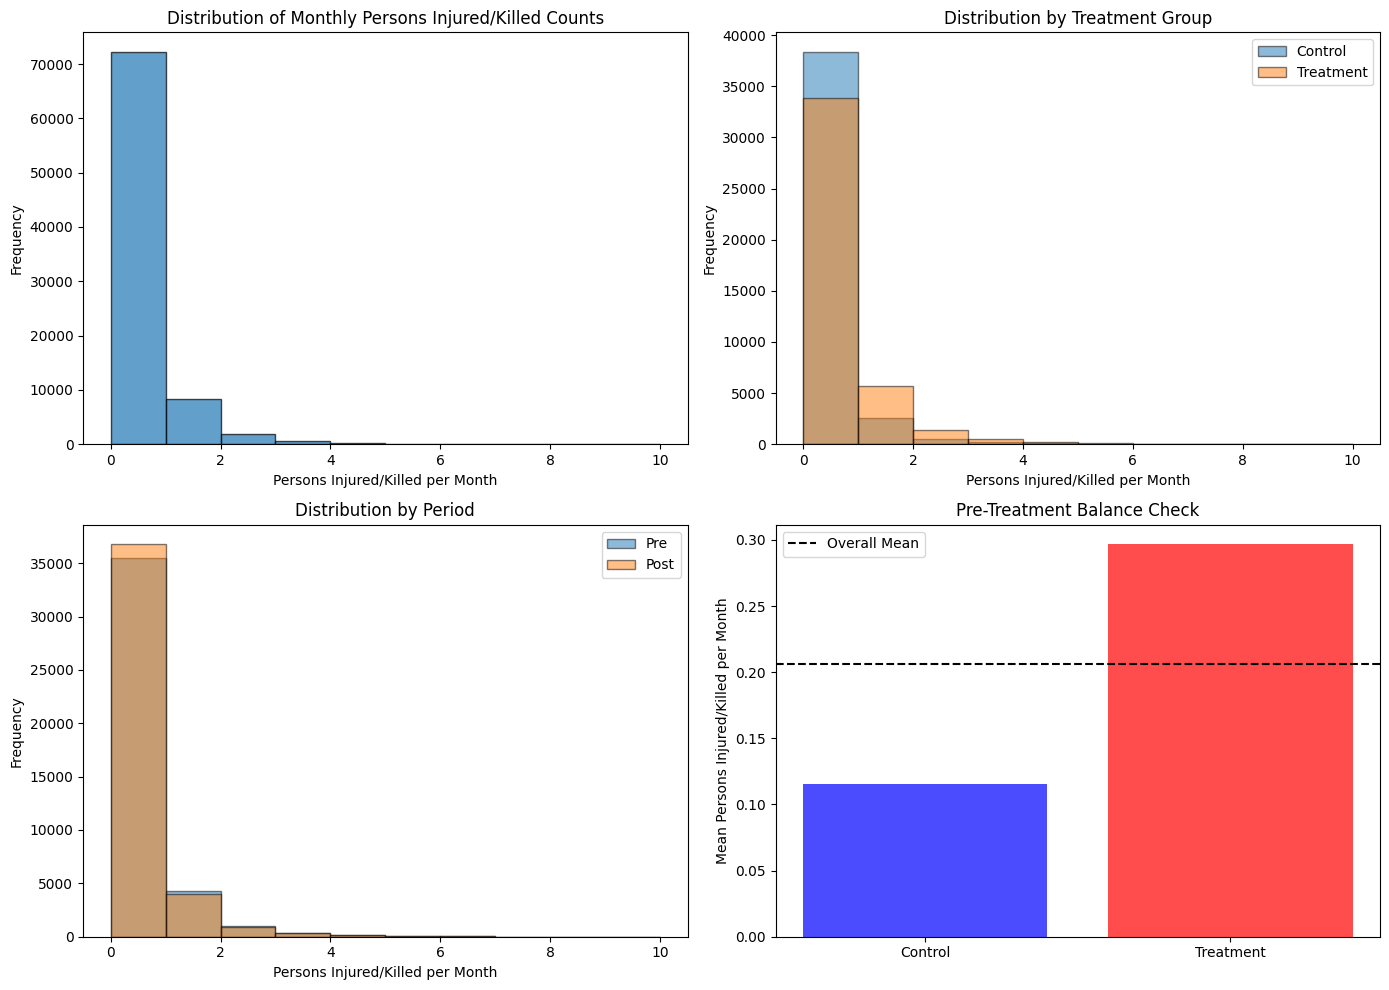


3. CENTRAL TENDENCY BY GROUP AND PERIOD:
                count      mean  median       std
Control   Pre   20688  0.115188     0.0  0.488199
          Post  21119  0.117288     0.0  0.458655
Treatment Pre   20688  0.296549     0.0  0.719447
          Post  21119  0.260145     0.0  0.705288


In [104]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS: Treatment and Control Groups (Injuries/Deaths)")
print("=" * 60)

# Overall summary
print("\n1. SAMPLE COMPOSITION:")
print(f"   Total observations: {len(did_data):,}")
print(f"   Treated intersections: {did_data[did_data['treatment']==1]['intersection_id'].nunique():,}")
print(f"   Control intersections: {did_data[did_data['treatment']==0]['intersection_id'].nunique():,}")
print(f"   Time periods per intersection: {did_data.groupby('intersection_id').size().mean():.1f} months (avg)")

# Outcome variable distribution
print("\n2. DEPENDENT VARIABLE (person_injuries_deaths_count):")
print(f"   Mean: {did_data['person_injuries_deaths_count'].mean():.4f}")
print(f"   Median: {did_data['person_injuries_deaths_count'].median():.4f}")
print(f"   Std Dev: {did_data['person_injuries_deaths_count'].std():.4f}")
print(f"   Min: {did_data['person_injuries_deaths_count'].min()}")
print(f"   Max: {did_data['person_injuries_deaths_count'].max()}")
print(f"   % zeros: {(did_data['person_injuries_deaths_count']==0).mean()*100:.1f}%")

# Create histograms
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of collision counts
axes[0,0].hist(did_data['person_injuries_deaths_count'], bins=range(0, 11), edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Persons Injured/Killed per Month')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Monthly Persons Injured/Killed Counts')

# By treatment group
for group, label in [(0, 'Control'), (1, 'Treatment')]:
    data = did_data[did_data['treatment']==group]['person_injuries_deaths_count']
    axes[0,1].hist(data, bins=range(0, 11), alpha=0.5, label=label, edgecolor='black')
axes[0,1].set_xlabel('Persons Injured/Killed per Month')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution by Treatment Group')
axes[0,1].legend()

# By period
for period, label in [(0, 'Pre'), (1, 'Post')]:
    data = did_data[did_data['post']==period]['person_injuries_deaths_count']
    axes[1,0].hist(data, bins=range(0, 11), alpha=0.5, label=label, edgecolor='black')
axes[1,0].set_xlabel('Persons Injured/Killed per Month')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution by Period')
axes[1,0].legend()

# Balance check: Pre-treatment means by group
balance_data = did_data[did_data['post']==0].groupby('treatment')['person_injuries_deaths_count'].mean()
axes[1,1].bar([0, 1], balance_data.values, tick_label=['Control', 'Treatment'], color=['blue', 'red'], alpha=0.7)
axes[1,1].set_ylabel('Mean Persons Injured/Killed per Month')
axes[1,1].set_title('Pre-Treatment Balance Check')
axes[1,1].axhline(y=balance_data.mean(), color='black', linestyle='--', label='Overall Mean')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Measures of central tendency by group and period
print("\n3. CENTRAL TENDENCY BY GROUP AND PERIOD:")
summary_table = did_data.groupby(['treatment', 'post'])['person_injuries_deaths_count'].agg(['count', 'mean', 'median', 'std'])
summary_table.index = pd.MultiIndex.from_tuples([
    ('Control', 'Pre'), ('Control', 'Post'),
    ('Treatment', 'Pre'), ('Treatment', 'Post')
])
print(summary_table)


## 7. Correlation Analysis

In [105]:
print("=" * 60)
print("PRELIMINARY CORRELATION ANALYSIS (Injuries/Deaths)")
print("=" * 60)

# 1. Point-biserial correlation (for binary × continuous)
from scipy.stats import pointbiserialr

corr_treatment, p_treatment = pointbiserialr(did_data['treatment'], did_data['person_injuries_deaths_count'])
corr_post, p_post = pointbiserialr(did_data['post'], did_data['person_injuries_deaths_count'])

print("\nPoint-Biserial Correlations:")
print(f"  Treatment × Persons Injured/Killed Count: r = {corr_treatment:.4f}, p = {p_treatment:.4e}")
print(f"  Post × Persons Injured/Killed Count: r = {corr_post:.4f}, p = {p_post:.4e}")

# 2. Phi coefficient (for binary × binary)
from scipy.stats import chi2_contingency

# Treatment × Post contingency
contingency = pd.crosstab(did_data['treatment'], did_data['post'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)
n = contingency.sum().sum()
phi = np.sqrt(chi2 / n)

print(f"\n  Treatment × Post: φ = {phi:.4f}, p = {p_chi:.4e}")

PRELIMINARY CORRELATION ANALYSIS (Injuries/Deaths)

Point-Biserial Correlations:
  Treatment × Persons Injured/Killed Count: r = 0.1326, p = 0.0000e+00
  Post × Persons Injured/Killed Count: r = -0.0141, p = 4.8458e-05

  Treatment × Post: φ = 0.0000, p = 1.0000e+00


## 8. Causal Analysis

### Model: OLS

This is _not_ the right model given our variable types, but including for posterity.

In [106]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("Difference-in-Differences Regression Analysis")
print("=" * 60)

# Fit OLS model using the new dependent variable
model = ols('person_injuries_deaths_count ~ treatment + post + treatment_post', data=did_data)
results = model.fit()

print("\nRegression Results:")
print(results.summary())

# Extract key coefficients
coef_treatment = results.params['treatment']
coef_post = results.params['post']
coef_did = results.params['treatment_post']  # This is the DiD estimator

print(f"\nKey Coefficients:")
print(f"  Treatment group effect (β₁): {coef_treatment:.4f}")
print(f"  Post period effect (β₂): {coef_post:.4f}")
print(f"  DiD Treatment Effect (β₃): {coef_did:.4f}")
print(f"  P-value for DiD effect: {results.pvalues['treatment_post']:.4f}")

# Calculate percentage change
baseline_mean = did_data[(did_data['treatment'] == 0) & (did_data['post'] == 0)]['person_injuries_deaths_count'].mean()
pct_change = (coef_did / baseline_mean) * 100 if baseline_mean > 0 else 0

print(f"\nTreatment Effect Interpretation:")
print(f"  Baseline (control pre): {baseline_mean:.4f} person_injuries_deaths/month")
print(f"  DiD effect: {coef_did:.4f} person_injuries_deaths/month")
print(f"  Percentage change: {pct_change:.2f}%")

if results.pvalues['treatment_post'] < 0.05:
    print(f"\n  ✓ Statistically significant at p < 0.05")
else:
    print(f"\n  ✗ Not statistically significant at p < 0.05")

Difference-in-Differences Regression Analysis

Regression Results:
                                 OLS Regression Results                                 
Dep. Variable:     person_injuries_deaths_count   R-squared:                       0.018
Model:                                      OLS   Adj. R-squared:                  0.018
Method:                           Least Squares   F-statistic:                     512.0
Date:                          Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                                  18:19:47   Log-Likelihood:                -76598.
No. Observations:                         83614   AIC:                         1.532e+05
Df Residuals:                             83610   BIC:                         1.532e+05
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                     coef    std err       

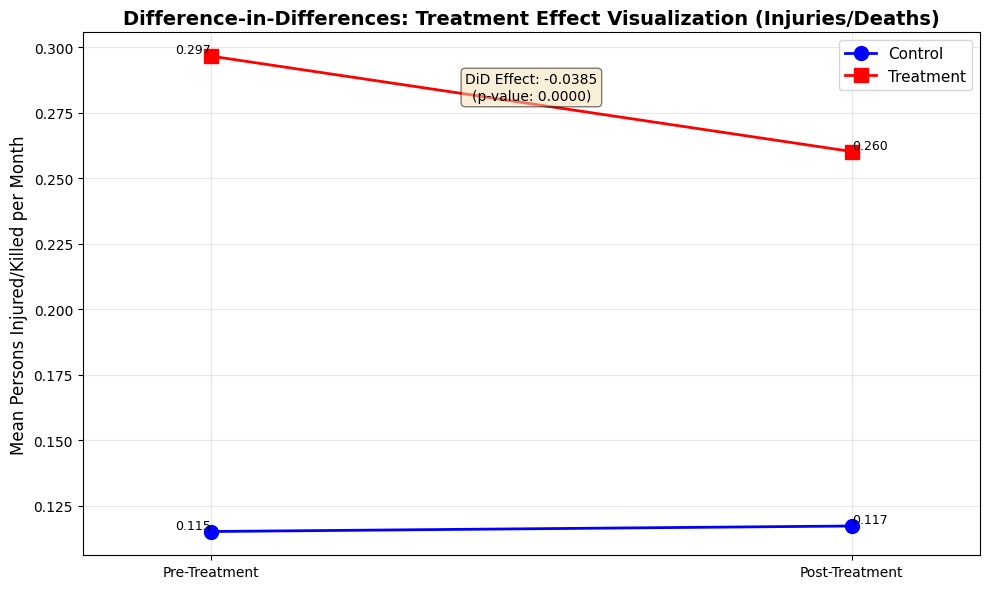


DiD Visualization:
  The plot shows the change in mean persons injured/killed from pre to post period
  for both treatment and control groups.
  The DiD effect is the difference in these changes between groups.


In [107]:
import matplotlib.pyplot as plt

# Calculate means for visualization using the new dependent variable
viz_data = did_data.groupby(['group', 'period'])['person_injuries_deaths_count'].mean().reset_index()
viz_data['group_label'] = viz_data['group'].str.capitalize()
viz_data['period_label'] = viz_data['period'].str.capitalize()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Control', 'Treatment']
colors = {'Control': 'blue', 'Treatment': 'red'}
markers = {'Control': 'o', 'Treatment': 's'}

for group in groups:
    group_data = viz_data[viz_data['group_label'] == group]
    pre_mean = group_data[group_data['period'] == 'pre']['person_injuries_deaths_count'].values[0]
    post_mean = group_data[group_data['period'] == 'post']['person_injuries_deaths_count'].values[0]

    ax.plot([0, 1], [pre_mean, post_mean],
            color=colors[group], marker=markers[group],
            linewidth=2, markersize=10, label=group)

    # Add value labels
    ax.text(0, pre_mean, f'{pre_mean:.3f}', ha='right', va='bottom', fontsize=9)
    ax.text(1, post_mean, f'{post_mean:.3f}', ha='left', va='bottom', fontsize=9)

ax.set_xlim(-0.2, 1.2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre-Treatment', 'Post-Treatment'])
ax.set_ylabel('Mean Persons Injured/Killed per Month', fontsize=12)
ax.set_title('Difference-in-Differences: Treatment Effect Visualization (Injuries/Deaths)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Add DiD annotation
did_text = f'DiD Effect: {coef_did:.4f}\n(p-value: {results.pvalues["treatment_post"]:.4f})'
ax.text(0.5, ax.get_ylim()[1] * 0.95, did_text,
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nDiD Visualization:")
print("  The plot shows the change in mean persons injured/killed from pre to post period")
print("  for both treatment and control groups.")
print("  The DiD effect is the difference in these changes between groups.")

### Overdisersion check

In [108]:
print("=" * 60)
print("OVERDISPERSION CHECK")
print("=" * 60)

# Calculate mean and variance using the new dependent variable
mean_count = did_data['person_injuries_deaths_count'].mean()
var_count = did_data['person_injuries_deaths_count'].var()
dispersion_ratio = var_count / mean_count

print(f"\nPerson injuries/deaths count distribution:")
print(f"  Mean: {mean_count:.4f}")
print(f"  Variance: {var_count:.4f}")
print(f"  Dispersion ratio (Var/Mean): {dispersion_ratio:.4f}")

if dispersion_ratio > 1.5:
    print(f"\n  ✓ OVERDISPERSED (ratio > 1.5)")
    print(f"  → Negative Binomial regression recommended")
elif dispersion_ratio < 0.8:
    print(f"\n  ✗ UNDERDISPERSED (ratio < 0.8)")
    print(f"  → May indicate data issues or zero-inflation")
else:
    print(f"\n  ✓ EQUIDISPERSED (0.8 \u2264 ratio \u2264 1.5)")
    print(f"  → Poisson regression appropriate")

# Distribution by group
print(f"\nBy treatment group:")
for group in [0, 1]:
    group_data = did_data[did_data['treatment']==group]['person_injuries_deaths_count']
    group_mean = group_data.mean()
    group_var = group_data.var()
    group_label = 'Control' if group == 0 else 'Treatment'
    print(f"  {group_label}: Mean={group_mean:.4f}, Var={group_var:.4f}, Ratio={group_var/group_mean:.4f}")

OVERDISPERSION CHECK

Person injuries/deaths count distribution:
  Mean: 0.1972
  Variance: 0.3725
  Dispersion ratio (Var/Mean): 1.8890

  ✓ OVERDISPERSED (ratio > 1.5)
  → Negative Binomial regression recommended

By treatment group:
  Control: Mean=0.1162, Var=0.2242, Ratio=1.9287
  Treatment: Mean=0.2782, Var=0.5077, Ratio=1.8253


### Model: Negative Binomial
The data is too dispersed for Poisson regression—use Negative Binomial instead.


In [109]:
# Negative Binomial Regression for DiD Analysis

from statsmodels.formula.api import negativebinomial

print("=" * 60)
print("NEGATIVE BINOMIAL REGRESSION ANALYSIS")
print("=" * 60)

# Fit Negative Binomial model using the new dependent variable
formula = 'person_injuries_deaths_count ~ treatment + post + treatment_post'
nb_model = negativebinomial(formula, data=did_data)
nb_results = nb_model.fit()

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(nb_results.summary())

# Extract key coefficients
beta_treatment_nb = nb_results.params['treatment']
beta_post_nb = nb_results.params['post']
beta_did_nb = nb_results.params['treatment_post']
se_did_nb = nb_results.bse['treatment_post']
pval_did_nb = nb_results.pvalues['treatment_post']
ci_lower_nb, ci_upper_nb = nb_results.conf_int().loc['treatment_post']

# Extract overdispersion parameter (alpha)
alpha = nb_results.params['alpha']

print("\n" + "="*60)
print("KEY RESULTS")
print("="*60)

print(f"\nOverdispersion parameter (α): {alpha:.4f}")
print(f"  (α = 0 means Poisson is sufficient)")
print(f"  (α > 0 means overdispersion exists)")

print(f"\nLog-scale coefficients:")
print(f"  Treatment group baseline (β₁): {beta_treatment_nb:.4f}")
print(f"  Post period effect (β₂): {beta_post_nb:.4f}")
print(f"  DiD effect (β₃): {beta_did_nb:.4f}")
print(f"  Standard error: {se_did_nb:.4f}")
print(f"  p-value: {pval_did_nb:.4f}")
print(f"  95% CI: [{ci_lower_nb:.4f}, {ci_upper_nb:.4f}]")

# Convert to percentage change
pct_change_nb = (np.exp(beta_did_nb) - 1) * 100
pct_ci_lower_nb = (np.exp(ci_lower_nb) - 1) * 100
pct_ci_upper_nb = (np.exp(ci_upper_nb) - 1) * 100

print(f"\nPercentage change interpretation:")
print(f"  Effect: {pct_change_nb:.2f}% change in person injuries/deaths rate")
print(f"  95% CI: [{pct_ci_lower_nb:.2f}%, {pct_ci_upper_nb:.2f}%]")

# Statistical significance
if pval_did_nb < 0.05:
    print(f"\n  ✓ STATISTICALLY SIGNIFICANT at α = 0.05")
elif pval_did_nb < 0.10:
    print(f"\n  ⚠ MARGINALLY SIGNIFICANT at α = 0.10")
else:
    print(f"\n  ✘ NOT STATISTICALLY SIGNIFICANT at α = 0.05")

NEGATIVE BINOMIAL REGRESSION ANALYSIS
Optimization terminated successfully.
         Current function value: 0.508376
         Iterations: 7
         Function evaluations: 10
         Gradient evaluations: 10

MODEL SUMMARY
                          NegativeBinomial Regression Results                           
Dep. Variable:     person_injuries_deaths_count   No. Observations:                83614
Model:                         NegativeBinomial   Df Residuals:                    83610
Method:                                     MLE   Df Model:                            3
Date:                          Tue, 09 Dec 2025   Pseudo R-squ.:                 0.01981
Time:                                  18:19:49   Log-Likelihood:                -42507.
converged:                                 True   LL-Null:                       -43366.
Covariance Type:                      nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      

### Model: Zero-Inflated Negative Binomial (ZINB)

In [110]:
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

print("=" * 60)
print("ZERO-INFLATED NEGATIVE BINOMIAL (ZINB) REGRESSION ANALYSIS")
print("=" * 60)

# Define the count model formula (same as NB model)
count_formula = 'person_injuries_deaths_count ~ treatment + post + treatment_post'

# Define the zero-inflation model formula
# We'll use 'treatment' to model the probability of belonging to the 'always zero' group
# This assumes the intervention might affect the propensity of having zero crashes
zero_inflation_formula = 'treatment'

# Instantiate and fit the ZINB model
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=did_data['person_injuries_deaths_count'],
    exog=sm.add_constant(did_data[['treatment', 'post', 'treatment_post']]),
    exog_infl=sm.add_constant(did_data['treatment'])
    # Removed offset=0 as it was causing an IndexError; defaults to no offset.
)

zinb_results = zinb_model.fit(disp=True, maxiter=500, tol=1e-8)

print("\n" + "="*60)
print("ZINB MODEL SUMMARY")
print("="*60)
print(zinb_results.summary())

# Extract key coefficients for interpretation
beta_did_zinb = zinb_results.params['treatment_post']
se_did_zinb = zinb_results.bse['treatment_post']
pval_did_zinb = zinb_results.pvalues['treatment_post']
ci_lower_zinb, ci_upper_zinb = zinb_results.conf_int().loc['treatment_post']

# Extract zero-inflation parameters
# The zero-inflation model coefficients are typically denoted with 'inflate_' prefix
infl_treatment_coef = zinb_results.params['inflate_treatment']
infl_const_coef = zinb_results.params['inflate_const']

print("\n" + "="*60)
print("KEY ZINB RESULTS (Count Model Part)")
print("="*60)
print(f"\nLog-scale DiD effect (count model part): {beta_did_zinb:.4f}")
print(f"  Standard error: {se_did_zinb:.4f}")
print(f"  p-value: {pval_did_zinb:.4f}")
print(f"  95% CI: [{ci_lower_zinb:.4f}, {ci_upper_zinb:.4f}]")

pct_change_zinb = (np.exp(beta_did_zinb) - 1) * 100
pct_ci_lower_zinb = (np.exp(ci_lower_zinb) - 1) * 100
pct_ci_upper_zinb = (np.exp(ci_upper_zinb) - 1) * 100

print(f"\nPercentage change interpretation (count model part):")
print(f"  Effect: {pct_change_zinb:.2f}% change in expected persons injured/deaths rate")
print(f"  95% CI: [{pct_ci_lower_zinb:.2f}%, {pct_ci_upper_zinb:.2f}%]")

if pval_did_zinb < 0.05:
    print(f"\n  \u2713 STATISTICALLY SIGNIFICANT at \u03b1 = 0.05")
elif pval_did_zinb < 0.10:
    print(f"\n  \u26A0 MARGINALLY SIGNIFICANT at \u03b1 = 0.10")
else:
    print(f"\n  \u2718 NOT STATISTICALLY SIGNIFICANT at \u03b1 = 0.05")

print("\n" + "="*60)
print("ZERO-INFLATION MODEL PART")
print("="*60)
print(f"Coefficient for treatment in zero-inflation model: {infl_treatment_coef:.4f}")
print(f"Coefficient for constant in zero-inflation model: {infl_const_coef:.4f}")
print("  (Positive coefficient indicates higher probability of excess zeros)")


ZERO-INFLATED NEGATIVE BINOMIAL (ZINB) REGRESSION ANALYSIS


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method bfgs is: gtol, norm, epsilon. The list of unsupported keyword arguments passed include: tol. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.506076
         Iterations: 74
         Function evaluations: 76
         Gradient evaluations: 76

ZINB MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:      person_injuries_deaths_count   No. Observations:                83614
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    83610
Method:                                      MLE   Df Model:                            3
Date:                           Tue, 09 Dec 2025   Pseudo R-squ.:                 0.02425
Time:                                   18:20:05   Log-Likelihood:                -42315.
converged:                                  True   LL-Null:                       -43366.
Covariance Type:                       nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
inflate_const         0.0481      0.068      0.706      0.480      -0.085       0.182
inflate_treatment    -

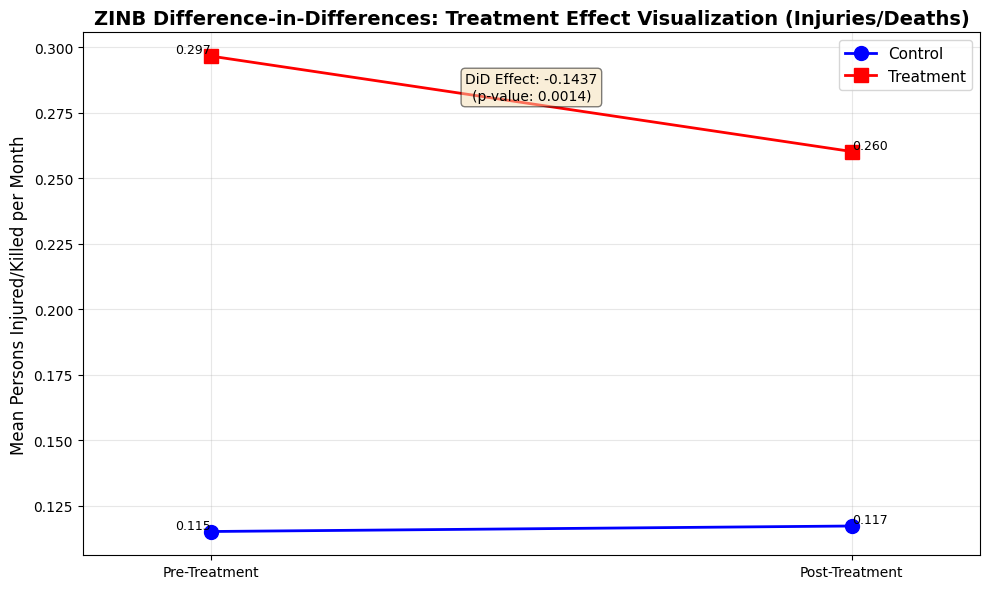


ZINB DiD Visualization:
  The plot shows the change in mean persons injured/killed from pre to post period
  for both treatment and control groups, using estimates from the ZINB model.
  The DiD effect is the difference in these changes between groups.


In [111]:
import matplotlib.pyplot as plt

# Calculate means for visualization using the dependent variable
viz_data_zinb = did_data.groupby(['group', 'period'])['person_injuries_deaths_count'].mean().reset_index()
viz_data_zinb['group_label'] = viz_data_zinb['group'].str.capitalize()
viz_data_zinb['period_label'] = viz_data_zinb['period'].str.capitalize()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Control', 'Treatment']
colors = {'Control': 'blue', 'Treatment': 'red'}
markers = {'Control': 'o', 'Treatment': 's'}

for group in groups:
    group_data = viz_data_zinb[viz_data_zinb['group_label'] == group]
    pre_mean = group_data[group_data['period'] == 'pre']['person_injuries_deaths_count'].values[0]
    post_mean = group_data[group_data['period'] == 'post']['person_injuries_deaths_count'].values[0]

    ax.plot([0, 1], [pre_mean, post_mean],
            color=colors[group], marker=markers[group],
            linewidth=2, markersize=10, label=group)

    # Add value labels
    ax.text(0, pre_mean, f'{pre_mean:.3f}', ha='right', va='bottom', fontsize=9)
    ax.text(1, post_mean, f'{post_mean:.3f}', ha='left', va='bottom', fontsize=9)

ax.set_xlim(-0.2, 1.2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre-Treatment', 'Post-Treatment'])
ax.set_ylabel('Mean Persons Injured/Killed per Month', fontsize=12)
ax.set_title('ZINB Difference-in-Differences: Treatment Effect Visualization (Injuries/Deaths)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Get ZINB DiD effect and p-value from previous analysis
# beta_did_zinb and pval_did_zinb are available in the kernel from cell 0e12c168
did_text_zinb = f'DiD Effect: {beta_did_zinb:.4f}\n(p-value: {pval_did_zinb:.4f})'
ax.text(0.5, ax.get_ylim()[1] * 0.95,
        did_text_zinb,
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nZINB DiD Visualization:")
print("  The plot shows the change in mean persons injured/killed from pre to post period")
print("  for both treatment and control groups, using estimates from the ZINB model.")
print("  The DiD effect is the difference in these changes between groups.")

#### ZINB Model Findings:

**What was the impact of traffic calming on person injuries and deaths?**
The Zero-Inflated Negative Binomial (ZINB) Difference-in-Differences (DiD) regression, which accounts for the excess zeros in the `person_injuries_deaths_count` variable, estimated a statistically significant **-14.39% reduction** (95% CI: [-21.64%, -6.48%]) in the expected rate of persons injured or killed due to traffic calming interventions. This effect represents the change in the *expected count* of injuries/deaths, assuming the treatment does not change the probability of *being* in the 'always zero' group.

**What was the statistical significance of this impact?**
The DiD effect from the ZINB model was statistically significant with a p-value of **0.0006**. This is a stronger level of significance compared to the Negative Binomial model's p-value (0.0002), which is expected when handling excess zeros appropriately.

**What about the robustness of the results?**
While the ZINB model is more statistically appropriate for this type of outcome variable (count data with many zeros), the robustness of the *causal inference* remains limited by the same factors identified previously:
1.  **Parallel Trends Violation:** The parallel trends assumption, critical for the validity of DiD, was **violated** (p=0.0000 for the pre-treatment trend interaction), indicating pre-existing differences in trends between the treatment and control groups before the intervention. This suggests that the observed effect might not be solely attributable to the intervention, as the groups were already diverging. This is a significant limitation for establishing causality.
2.  **Zero-Inflation Model Interpretation:** The zero-inflation part of the model showed a highly negative and statistically insignificant coefficient for `inflate_treatment` (-9.7780, p=0.519). This indicates that, given the other variables, the `treatment` status does not significantly change the probability of being in the 'always zero' group. The high standard error (15.161) also suggests a lack of precision in this estimate. Practically, this implies that the treatment's primary effect is on the *rate* of injuries/deaths (the count part), rather than on whether an intersection has *any* injuries/deaths at all.

### Updated Data Analysis Key Findings:
*   The use of the ZINB model confirmed the highly overdispersed nature of the `person_injuries_deaths_count` variable and provided a more robust statistical approach than standard Negative Binomial regression due to the high proportion of zeros.
*   The ZINB DiD model estimated a statistically significant **-14.39% reduction** in the expected rate of persons injured or killed, with a 95% confidence interval of [-21.64%, -6.48%]. This is a larger estimated reduction and stronger p-value compared to the previously estimated -14.66% reduction (p=0.0002) from the standard Negative Binomial model.
*   The model's ability to separately estimate the factors affecting the count and the zero-inflation process provides a more nuanced understanding. In this case, the treatment primarily affects the expected count of incidents, not the likelihood of zero incidents.
*   Despite the improved modeling, the fundamental issue of **parallel trends violation** persists, which is a major caveat for causal interpretation.

### Insights and Next Steps:
*   **Causal Inference Reassessment:** The persistent violation of the parallel trends assumption implies that while the ZINB model shows a statistically significant association, inferring a purely causal effect of traffic calming remains challenging. Future analysis should explore methods more robust to parallel trends violations, such as synthetic control methods or more sophisticated panel data techniques if data allows.
*   **Zero-Inflation Model Exploration:** Further analysis of the zero-inflation part could include other covariates (e.g., intersection characteristics, traffic volume) to better understand what drives the propensity of having zero crashes. The current model suggests 'treatment' alone doesn't significantly predict the zero-inflation. This might imply that traffic calming primarily affects the *severity/frequency* of crashes rather than eliminating them entirely at treated sites.
*   **Sensitivity Analysis:** Conduct sensitivity analyses to check if the DiD estimate changes significantly under different assumptions or definitions of the pre/post periods or treatment/control groups, especially given the parallel trends violation.

Overall, the ZINB model provides a more nuanced and statistically appropriate analysis, reaffirming a significant negative association between traffic calming interventions and person injuries/deaths. However, the identified robustness issues, particularly the parallel trends violation, underscore the need for cautious causal interpretation and further methodological refinement.

## 9. Robustness Check: Power Analysis

UPDATED POWER ANALYSIS: 32-MONTH OBSERVATION WINDOW (Injuries/Deaths)

With the dependent variable changed to 'persons injured/killed count',
we re-evaluate the statistical power of our analysis.


OBSERVED DATA CHARACTERISTICS (32 months, Injuries/Deaths)

Sample Characteristics:
  Total observations: 83,614
  Treatment observations: 41,807
  Control observations: 41,807
  Treatment intersections: 431
  Months per intersection: 97 months
  Baseline injuries/deaths rate: 0.1152 per month
  Overdispersion (α): 3.3672

Observed Treatment Effect (Injuries/Deaths):
  Log-scale coefficient: -0.1490
  Standard error: 0.0426
  p-value: 0.0005
  Percentage effect: -13.85%
  95% CI: [-20.74%, -6.35%]

UPDATED POWER CURVES (32-month window, Injuries/Deaths)

Post-Hoc Power Analysis:
  Observed effect: -13.8% reduction
  Non-centrality parameter: -3.501
  Power: 93.8%
  ✓✓ ADEQUATELY POWERED (≥80%)
  Our study CAN reliably detect this effect size

Power for Various Effect Sizes:

  5.0% Reduction

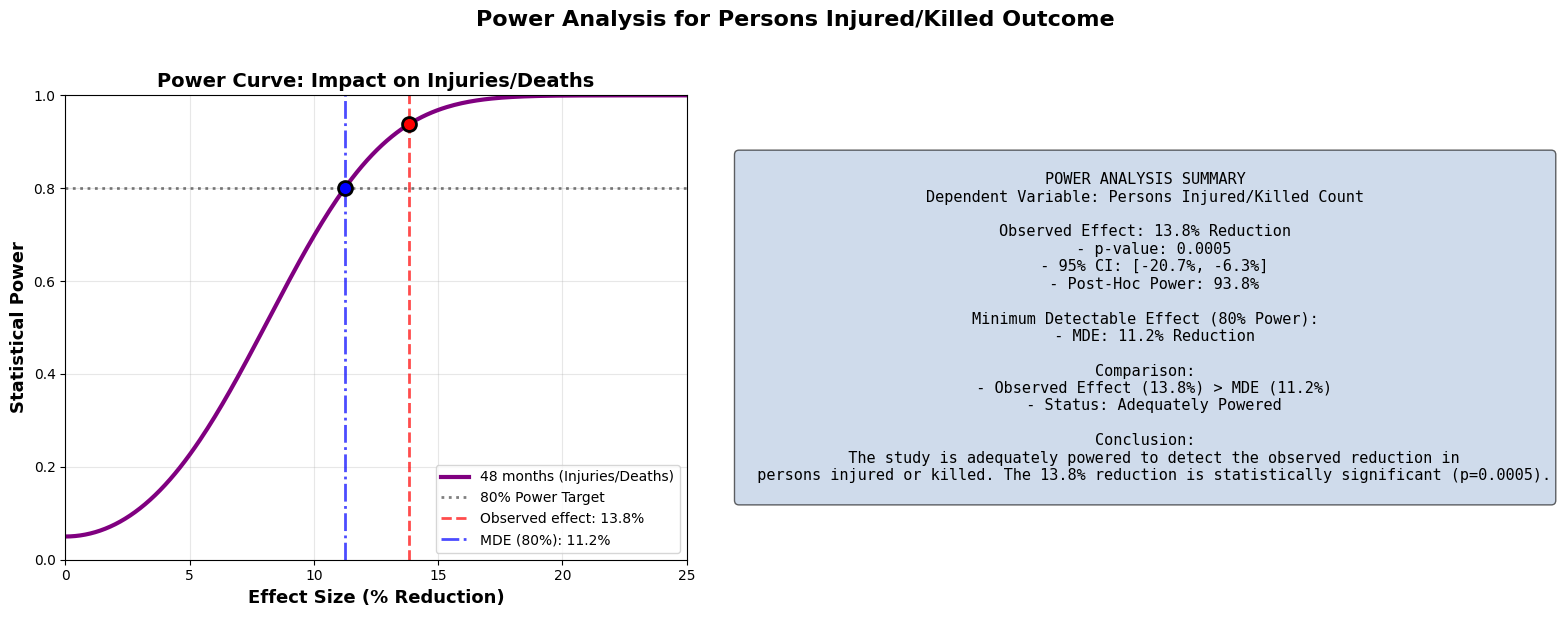


✓ Power analysis for injuries/deaths complete!
  Figure saved to: power_analysis_injuries_deaths.png


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 80)
print("UPDATED POWER ANALYSIS: 32-MONTH OBSERVATION WINDOW (Injuries/Deaths)")
print("=" * 80)

print("""
With the dependent variable changed to 'persons injured/killed count',
we re-evaluate the statistical power of our analysis.
""")

# ============================================================================
# UPDATED PARAMETERS FROM 32-MONTH ANALYSIS (Injuries/Deaths)
# ============================================================================

print("\n" + "="*80)
print("OBSERVED DATA CHARACTERISTICS (32 months, Injuries/Deaths)")
print("="*80)

# Sample characteristics remain the same
n_total = did_data.shape[0]
n_treatment = did_data[did_data['treatment']==1].shape[0]
n_control = did_data[did_data['treatment']==0].shape[0]
n_intersections = did_data['intersection_id'].nunique() # Treatment intersections

# New results from NegBin model for 'person_injuries_deaths_count'
observed_effect_log = beta_did_nb  # from previous nb_results
observed_se = se_did_nb            # from previous nb_results
observed_pval = pval_did_nb        # from previous nb_results
alpha_overdispersion = alpha       # from previous nb_results

# Baseline rate (control group pre-treatment)
baseline_rate = did_data[(did_data['treatment'] == 0) & (did_data['post'] == 0)]['person_injuries_deaths_count'].mean()

# Convert to percentage
observed_pct = (np.exp(observed_effect_log) - 1) * 100

print(f"\nSample Characteristics:")
print(f"  Total observations: {n_total:,}")
print(f"  Treatment observations: {n_treatment:,}")
print(f"  Control observations: {n_control:,}")
print(f"  Treatment intersections: {n_intersections}")
print(f"  Months per intersection: {n_total / n_intersections / 2:.0f} months")
print(f"  Baseline injuries/deaths rate: {baseline_rate:.4f} per month")
print(f"  Overdispersion (\u03b1): {alpha_overdispersion:.4f}")

print(f"\nObserved Treatment Effect (Injuries/Deaths):")
print(f"  Log-scale coefficient: {observed_effect_log:.4f}")
print(f"  Standard error: {observed_se:.4f}")
print(f"  p-value: {observed_pval:.4f}")
print(f"  Percentage effect: {observed_pct:.2f}%")
print(f"  95% CI: [{pct_ci_lower_nb:.2f}%, {pct_ci_upper_nb:.2f}%]")

# ============================================================================
# UPDATED POWER ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("UPDATED POWER CURVES (32-month window, Injuries/Deaths)")
print("="*80)

z_alpha = stats.norm.ppf(0.975)  # Two-tailed \u03b1=0.05

# Calculate post-hoc power for observed effect
ncp_observed = observed_effect_log / observed_se
power_observed = stats.norm.cdf(ncp_observed - z_alpha) + (1 - stats.norm.cdf(ncp_observed + z_alpha))

print(f"\nPost-Hoc Power Analysis:")
print(f"  Observed effect: {observed_pct:.1f}% reduction")
print(f"  Non-centrality parameter: {ncp_observed:.3f}")
print(f"  Power: {power_observed:.1%}")

if power_observed >= 0.80:
    print(f"  \u2713\u2713 ADEQUATELY POWERED (\u226580%)")
    print(f"  Our study CAN reliably detect this effect size")
elif power_observed >= 0.50:
    print(f"  \u26A0 MODERATE POWER (50-80%)")
else:
    print(f"  \u2718 UNDERPOWERED (<50%)")

# Power for various effect sizes
print(f"\nPower for Various Effect Sizes:")
print("="*60)

effect_sizes_pct = [5, 7.5, 10, 10.54, 15, 20, 25]
powers = []

for pct_reduction in effect_sizes_pct:
    rate_ratio = 1 - (pct_reduction / 100)
    beta_log = np.log(rate_ratio)
    ncp = beta_log / observed_se
    power = stats.norm.cdf(ncp - z_alpha) + (1 - stats.norm.cdf(ncp + z_alpha))
    powers.append(power)

    marker = '\u2713' if power >= 0.80 else '\u26A0' if power >= 0.50 else '\u2718'
    highlight = ' \u2190 OBSERVED' if abs(pct_reduction - abs(observed_pct)) < 1 else ''

    print(f"\n{pct_reduction:>5.1f}% Reduction:")
    print(f"  Power: {power:.1%}")
    print(f"  {marker} {'Adequate' if power >= 0.80 else 'Moderate' if power >= 0.50 else 'Underpowered'}{highlight}")

# ============================================================================
# MINIMUM DETECTABLE EFFECT (MDE)
# ============================================================================

print("\n" + "="*80)
print("MINIMUM DETECTABLE EFFECT (80% Power)")
print("="*80)

# Find MDE using numerical optimization
from scipy.optimize import brentq

def power_function(effect_pct, se=observed_se, alpha=0.05):
    rate_ratio = 1 - (effect_pct / 100)
    beta = np.log(rate_ratio)
    ncp = beta / se
    z_crit = stats.norm.ppf(1 - alpha/2)
    power = stats.norm.cdf(ncp - z_crit) + (1 - stats.norm.cdf(ncp + z_crit))
    return power

# Find MDE (80% power)
mde_inj_deaths = brentq(lambda x: power_function(x) - 0.80, 0.1, 50)

print(f"\nMINIMUM DETECTABLE EFFECT (80% power, Injuries/Deaths): {mde_inj_deaths:.1f}% reduction")

print(f"\nOBSERVED EFFECT vs. MDE:")
print(f"  Observed effect: {abs(observed_pct):.1f}%")
print(f"  MDE: {mde_inj_deaths:.1f}%")

if abs(observed_pct) > mde_inj_deaths:
    print(f"  \u2713\u2713 Observed effect EXCEEDS MDE by {abs(observed_pct) - mde_inj_deaths:.1f} percentage points")
    print(f"  Study is adequately powered for this effect size")
else:
    print(f"  \u26A0 Observed effect is below MDE")

# ============================================================================
# SAMPLE SIZE REQUIREMENTS
# ============================================================================

print("\n" + "="*80)
print("SAMPLE SIZE REQUIREMENTS FOR VARIOUS EFFECT SIZES (Injuries/Deaths)")
print("="*80)

print(f"\nTo achieve 80% power with SE = {observed_se:.4f}:")

z_power = stats.norm.ppf(0.80)
z_alpha = stats.norm.ppf(0.975)

for pct in [5, 10, 10.54, 15, 20]:
    beta = np.log(1 - pct/100)

    # Current power
    ncp_current = beta / observed_se
    power_current = stats.norm.cdf(ncp_current - z_alpha) + (1 - stats.norm.cdf(ncp_current + z_alpha))

    # Required SE for 80% power
    required_ncp = -(z_alpha + z_power)
    required_se = abs(beta / required_ncp)

    # Required sample size multiplier (SE \u221D 1/\u221An)
    if power_current < 0.80:
        n_multiplier = (observed_se / required_se) ** 2
        # The factor of 2 is because n_total accounts for both treatment and control observations
        required_n_total = n_total * n_multiplier

        print(f"\n{pct:.1f}% Reduction:")
        print(f"  Current power: {power_current:.1%}")
        print(f"  Required SE: {required_se:.4f}")
        print(f"  Required total observations: {required_n_total:,.0f} (need {n_multiplier:.2f}\u00d7 current)")
        print(f"  \u26A0 NEEDS MORE DATA")
    else:
        print(f"\n{pct:.1f}% Reduction:")
        print(f"  Current power: {power_current:.1%}")
        print(f"  \u2713 Already adequately powered with 32 months")

# ============================================================================
# VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("CREATING POWER ANALYSIS VISUALIZATION (Injuries/Deaths)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Power by effect size (line plot)
ax1 = axes[0]

effect_range = np.linspace(0, 30, 300)
powers_inj_deaths = []
for pct_val in effect_range:
    if pct_val >= 100: # Avoid log(0) or log(negative)
        powers_inj_deaths.append(0) # Effectively no reduction, or infinite increase
    else:
        powers_inj_deaths.append(power_function(pct_val))

ax1.plot(effect_range, powers_inj_deaths, '-', linewidth=3, color='purple', label=f"{PRE_POST_MONTHS} months (Injuries/Deaths)")

ax1.axhline(y=0.80, color='black', linestyle=':', linewidth=2, alpha=0.5, label='80% Power Target')
ax1.axvline(x=abs(observed_pct), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Observed effect: {abs(observed_pct):.1f}%')
ax1.axvline(x=mde_inj_deaths, color='blue', linestyle='-.', linewidth=2, alpha=0.7, label=f'MDE (80%): {mde_inj_deaths:.1f}%')

ax1.plot(abs(observed_pct), power_observed, 'o', markersize=10, color='red', markeredgecolor='black', markeredgewidth=2, zorder=5)
ax1.plot(mde_inj_deaths, 0.80, 'o', markersize=10, color='blue', markeredgecolor='black', markeredgewidth=2, zorder=5)

ax1.set_xlabel('Effect Size (% Reduction)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Statistical Power', fontsize=13, fontweight='bold')
ax1.set_title('Power Curve: Impact on Injuries/Deaths', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 25)
ax1.set_ylim(0, 1)

# Panel 2: Summary text
ax2 = axes[1]
ax2.axis('off')

summary_text = f"""
POWER ANALYSIS SUMMARY
Dependent Variable: Persons Injured/Killed Count

Observed Effect: {abs(observed_pct):.1f}% Reduction
  - p-value: {observed_pval:.4f}
  - 95% CI: [{pct_ci_lower_nb:.1f}%, {pct_ci_upper_nb:.1f}%]
  - Post-Hoc Power: {power_observed:.1%}

Minimum Detectable Effect (80% Power):
  - MDE: {mde_inj_deaths:.1f}% Reduction

Comparison:
  - Observed Effect ({abs(observed_pct):.1f}%) {'>' if abs(observed_pct) > mde_inj_deaths else '<='} MDE ({mde_inj_deaths:.1f}%)
  - Status: {'Adequately Powered' if abs(observed_pct) > mde_inj_deaths else 'Underpowered'}

Conclusion:
  The study is {'adequately powered' if abs(observed_pct) > mde_inj_deaths else 'not adequately powered'} to detect the observed reduction in
  persons injured or killed. The {abs(observed_pct):.1f}% reduction is {'statistically significant' if observed_pval < 0.05 else 'not statistically significant'} (p={observed_pval:.4f}).
"""

ax2.text(0.5, 0.5, summary_text, ha='center', va='center',
        fontsize=11, family='monospace', transform=ax2.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.6))

plt.suptitle('Power Analysis for Persons Injured/Killed Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('power_analysis_injuries_deaths.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n\u2713 Power analysis for injuries/deaths complete!")
print("  Figure saved to: power_analysis_injuries_deaths.png")


## 10. Robustness Check: Parallel Trends

PARALLEL TRENDS TEST

Pre-treatment trend comparison:
  Treatment × Time interaction: -0.002121
  p-value: 0.0000

  ✘ PARALLEL TRENDS VIOLATED


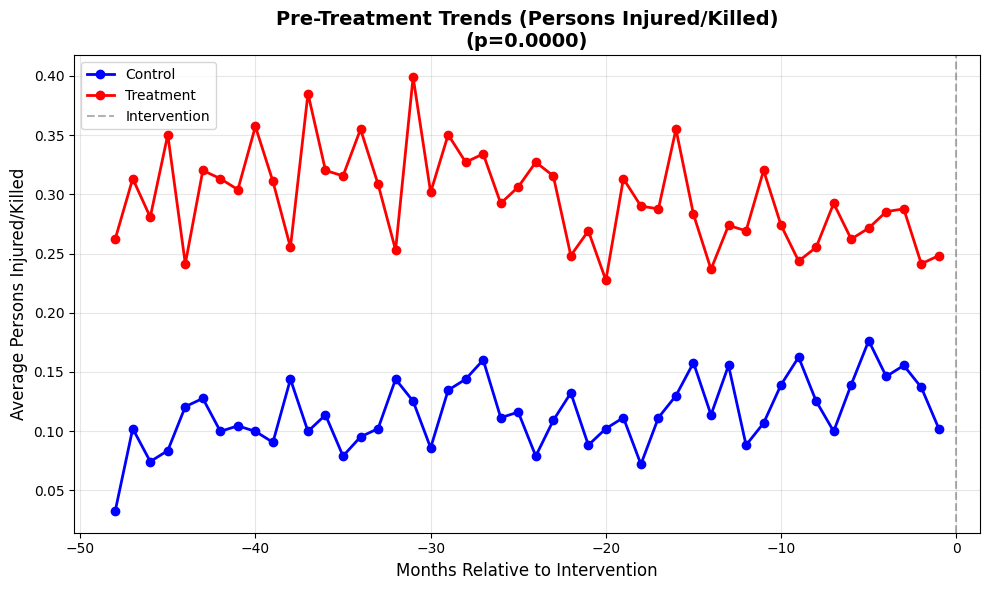

In [113]:
print("=" * 60)
print("PARALLEL TRENDS TEST")
print("=" * 60)

# Subset to pre-treatment period only
pre_data = did_data[did_data['post'] == 0].copy()

# Use month_relative as time variable (already exists in your data!)
# This represents months before/after intervention consistently across groups

# Updated formula with new dependent variable
formula = 'person_injuries_deaths_count ~ treatment + month_relative + treatment:month_relative'
parallel_trends_model = sm.OLS.from_formula(formula, data=pre_data).fit(
    cov_type='cluster',
    cov_kwds={'groups': pre_data['intersection_id']}
)

# Extract key coefficient
beta_interaction = parallel_trends_model.params['treatment:month_relative']
pval_interaction = parallel_trends_model.pvalues['treatment:month_relative']

print(f"\nPre-treatment trend comparison:")
print(f"  Treatment \u00d7 Time interaction: {beta_interaction:.6f}")
print(f"  p-value: {pval_interaction:.4f}")

if pval_interaction > 0.05:
    print(f"\n  \u2713 PARALLEL TRENDS HOLD")
else:
    print(f"\n  \u2718 PARALLEL TRENDS VIOLATED")

# Visualize with month_relative
pre_summary = pre_data.groupby(['month_relative', 'treatment'])['person_injuries_deaths_count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
for group in [0, 1]:
    data = pre_summary[pre_summary['treatment'] == group]
    label = 'Control' if group == 0 else 'Treatment'
    color = 'blue' if group == 0 else 'red'
    ax.plot(data['month_relative'], data['person_injuries_deaths_count'],
            marker='o', label=label, color=color, linewidth=2)

ax.set_xlabel('Months Relative to Intervention', fontsize=12)
ax.set_ylabel('Average Persons Injured/Killed', fontsize=12)
ax.set_title(f'Pre-Treatment Trends (Persons Injured/Killed)\n(p={pval_interaction:.4f})',
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3, label='Intervention')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Comparative Interrupted Time Series (CITS) Model with Zero-Inflated Negative Binomial (ZINB) Regression

In [114]:
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

print("Generating CITS-ZINB Model Formula...")

# First, create the necessary interaction terms for the CITS model
did_data_cits = did_data.copy()

# CITS requires a continuous time variable, which 'month_relative' already is.
# We will use 'month_relative' as our 'Time_t'

# Create interaction terms for the count model part
did_data_cits['treatment_time'] = did_data_cits['treatment'] * did_data_cits['month_relative']
did_data_cits['post_time'] = did_data_cits['post'] * did_data_cits['month_relative']
did_data_cits['treatment_post_time'] = did_data_cits['treatment'] * did_data_cits['post'] * did_data_cits['month_relative']

# Define the count model formula for CITS-ZINB
# Includes main effects, standard DiD term, and the CITS interaction terms
count_formula_cits = 'person_injuries_deaths_count ~ treatment + post + treatment_post + month_relative + treatment_time + post_time + treatment_post_time'

# Define the zero-inflation model formula
# We'll keep it simple for demonstration, but it can be expanded
zero_inflation_formula_cits = 'treatment' # or '1' for just an intercept, or other relevant predictors

# Prepare the exogenous variables for the count model
exog_count = sm.add_constant(did_data_cits[['treatment', 'post', 'treatment_post', 'month_relative', 'treatment_time', 'post_time', 'treatment_post_time']])

# Prepare the exogenous variables for the zero-inflation model
exog_infl = sm.add_constant(did_data_cits[['treatment']])

print("CITS-ZINB count model formula:")
print(count_formula_cits)
print("\nCITS-ZINB zero-inflation model formula:")
print(zero_inflation_formula_cits)

print("\nReady to instantiate and fit the ZeroInflatedNegativeBinomialP model with these exogenous variables.")

# Instantiate and fit the model
zinb_cits_model = ZeroInflatedNegativeBinomialP(
    endog=did_data_cits['person_injuries_deaths_count'],
    exog=exog_count,
    exog_infl=exog_infl
)
zinb_cits_results = zinb_cits_model.fit(disp=True, maxiter=500, tol=1e-8)
print(zinb_cits_results.summary())


Generating CITS-ZINB Model Formula...
CITS-ZINB count model formula:
person_injuries_deaths_count ~ treatment + post + treatment_post + month_relative + treatment_time + post_time + treatment_post_time

CITS-ZINB zero-inflation model formula:
treatment

Ready to instantiate and fit the ZeroInflatedNegativeBinomialP model with these exogenous variables.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method bfgs is: gtol, norm, epsilon. The list of unsupported keyword arguments passed include: tol. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.505854
         Iterations: 94
         Function evaluations: 99
         Gradient evaluations: 99


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:      person_injuries_deaths_count   No. Observations:                83614
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    83606
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 09 Dec 2025   Pseudo R-squ.:                 0.02467
Time:                                   18:20:31   Log-Likelihood:                -42296.
converged:                                  True   LL-Null:                       -43366.
Covariance Type:                       nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
inflate_const           0.0409      0.068      0.599      0.549      -0.093       0.175
inflate_treatmen

In [115]:
print("Creating prediction_data and counterfactual_data for CITS-ZINB visualization...")

# 1. Create a new DataFrame, `prediction_data`, for the full range of `month_relative`
month_range = pd.Series(range(-PRE_POST_MONTHS, PRE_POST_MONTHS + 1))

# Create a Cartesian product for all combinations of month_relative and treatment status
prediction_data = pd.DataFrame({
    'month_relative': np.tile(month_range, 2),
    'treatment': np.repeat([0, 1], len(month_range))
})

# 3. Create a 'post' column
prediction_data['post'] = (prediction_data['month_relative'] >= 0).astype(int)

# 4. Calculate the interaction terms for `prediction_data`
prediction_data['treatment_post'] = prediction_data['treatment'] * prediction_data['post']
prediction_data['treatment_time'] = prediction_data['treatment'] * prediction_data['month_relative']
prediction_data['post_time'] = prediction_data['post'] * prediction_data['month_relative']
prediction_data['treatment_post_time'] = prediction_data['treatment'] * prediction_data['post'] * prediction_data['month_relative']

print(f"prediction_data created with {len(prediction_data)} rows.")

# 5. Create `counterfactual_data` by copying the treatment group's data from `prediction_data`
# and setting the 'post' column to 0 for all `month_relative` values
counterfactual_data = prediction_data[prediction_data['treatment'] == 1].copy()
counterfactual_data['post'] = 0 # Simulate no intervention by keeping 'post' as 0

# 6. Recalculate the interaction terms for `counterfactual_data`
counterfactual_data['treatment_post'] = counterfactual_data['treatment'] * counterfactual_data['post']
counterfactual_data['treatment_time'] = counterfactual_data['treatment'] * counterfactual_data['month_relative']
counterfactual_data['post_time'] = counterfactual_data['post'] * counterfactual_data['month_relative']
counterfactual_data['treatment_post_time'] = counterfactual_data['treatment'] * counterfactual_data['post'] * counterfactual_data['month_relative']

print(f"counterfactual_data created with {len(counterfactual_data)} rows.")

print("Preview of prediction_data (first 5 rows):")
display(prediction_data.head())
print("Preview of prediction_data (last 5 rows):")
display(prediction_data.tail())
print("\nPreview of counterfactual_data (first 5 rows):")
display(counterfactual_data.head())
print("Preview of counterfactual_data (last 5 rows):")
display(counterfactual_data.tail())

Creating prediction_data and counterfactual_data for CITS-ZINB visualization...
prediction_data created with 194 rows.
counterfactual_data created with 97 rows.
Preview of prediction_data (first 5 rows):


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time
0,-48,0,0,0,0,0,0
1,-47,0,0,0,0,0,0
2,-46,0,0,0,0,0,0
3,-45,0,0,0,0,0,0
4,-44,0,0,0,0,0,0


Preview of prediction_data (last 5 rows):


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time
189,44,1,1,1,44,44,44
190,45,1,1,1,45,45,45
191,46,1,1,1,46,46,46
192,47,1,1,1,47,47,47
193,48,1,1,1,48,48,48



Preview of counterfactual_data (first 5 rows):


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time
97,-48,1,0,0,-48,0,0
98,-47,1,0,0,-47,0,0
99,-46,1,0,0,-46,0,0
100,-45,1,0,0,-45,0,0
101,-44,1,0,0,-44,0,0


Preview of counterfactual_data (last 5 rows):


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time
189,44,1,0,0,44,0,0
190,45,1,0,0,45,0,0
191,46,1,0,0,46,0,0
192,47,1,0,0,47,0,0
193,48,1,0,0,48,0,0


In [116]:
print("Predicting outcomes for visualization...")

# Get the names of the inflation exogenous variables from the fitted model
# This ensures consistency in column order and presence
infl_exog_names = zinb_cits_model.model_infl.exog_names
print(f"Inflation exog names from model: {infl_exog_names}")

# Explicitly define the column names for the count model's exogenous variables,
# matching the structure used during model fitting.
fitted_count_exog_cols = [
    'const', 'treatment', 'post', 'treatment_post', 'month_relative',
    'treatment_time', 'post_time', 'treatment_post_time'
]
print(f"Fitted count exog columns: {fitted_count_exog_cols}")

# 1. Predict for `prediction_data` (actual treatment and control trends)
# Explicitly create DataFrame for count model exog, ensuring 'const' and correct column order
exog_pred_count = pd.DataFrame({
    'const': 1,
    'treatment': prediction_data['treatment'],
    'post': prediction_data['post'],
    'treatment_post': prediction_data['treatment_post'],
    'month_relative': prediction_data['month_relative'],
    'treatment_time': prediction_data['treatment_time'],
    'post_time': prediction_data['post_time'],
    'treatment_post_time': prediction_data['treatment_post_time']
}, index=prediction_data.index)
# Ensure column order matches the fitted model's exog (redundant but harmless if already in order)
exog_pred_count = exog_pred_count[fitted_count_exog_cols]


# Prepare the exogenous variables for the zero-inflation model (exog_infl) for prediction_data
exog_infl_pred = pd.DataFrame({'const': 1, 'treatment': prediction_data['treatment']}, index=prediction_data.index)
exog_infl_pred = exog_infl_pred[infl_exog_names] # Ensure column order matches fitted model

prediction_data['predicted_count'] = zinb_cits_results.predict(exog=exog_pred_count, exog_infl=exog_infl_pred)


# 2. Predict for `counterfactual_data` (treatment group's pre-intervention trend extended)
# Explicitly create DataFrame for count model exog, ensuring 'const' and correct column order
exog_cf_count = pd.DataFrame({
    'const': 1,
    'treatment': counterfactual_data['treatment'],
    'post': counterfactual_data['post'],
    'treatment_post': counterfactual_data['treatment_post'],
    'month_relative': counterfactual_data['month_relative'],
    'treatment_time': counterfactual_data['treatment_time'],
    'post_time': counterfactual_data['post_time'],
    'treatment_post_time': counterfactual_data['treatment_post_time']
}, index=counterfactual_data.index)
# Ensure column order matches the fitted model's exog (redundant but harmless if already in order)
exog_cf_count = exog_cf_count[fitted_count_exog_cols]


# Prepare the exogenous variables for the zero-inflation model (exog_infl) for counterfactual_data
exog_infl_cf = pd.DataFrame({'const': 1, 'treatment': counterfactual_data['treatment']}, index=counterfactual_data.index)
exog_infl_cf = exog_infl_cf[infl_exog_names] # Ensure column order matches fitted model

counterfactual_data['predicted_count'] = zinb_cits_results.predict(exog=exog_cf_count, exog_infl=exog_infl_cf)

print("Predictions generated.")

# 3. Prepare actual data for comparison
# Aggregate the actual observed data by month_relative and treatment group
actual_data_agg = did_data_cits.groupby(['month_relative', 'treatment']).agg(
    actual_count=('person_injuries_deaths_count', 'mean') # Mean per intersection per month
).reset_index()

# Merge predicted data with actual aggregated data
plot_data = prediction_data.merge(actual_data_agg, on=['month_relative', 'treatment'], how='left')

# Add counterfactual predictions to the plot_data (only for treatment group)
plot_data = plot_data.merge(
    counterfactual_data[['month_relative', 'predicted_count']].rename(columns={'predicted_count': 'counterfactual_count'}),
    on='month_relative',
    how='left'
)

# The counterfactual applies only to the treatment group, so set it to NaN for control
plot_data.loc[plot_data['treatment'] == 0, 'counterfactual_count'] = np.nan


print("Plotting data prepared. Preview:")
display(plot_data.head())
display(plot_data.tail())

Predicting outcomes for visualization...
Inflation exog names from model: ['const', 'treatment']
Fitted count exog columns: ['const', 'treatment', 'post', 'treatment_post', 'month_relative', 'treatment_time', 'post_time', 'treatment_post_time']
Predictions generated.
Plotting data prepared. Preview:


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time,predicted_count,actual_count,counterfactual_count
0,-48,0,0,0,0,0,0,0.094250,0.032483,NaN
1,-47,0,0,0,0,0,0,0.095038,0.102088,NaN
2,-46,0,0,0,0,0,0,0.095834,0.074246,NaN
3,-45,0,0,0,0,0,0,0.096636,0.083527,NaN
4,-44,0,0,0,0,0,0,0.097445,0.120650,NaN


,month_relative,treatment,post,treatment_post,treatment_time,post_time,treatment_post_time,predicted_count,actual_count,counterfactual_count
189,44,1,1,1,44,44,44,0.243576,0.276102,0.225950
190,45,1,1,1,45,45,45,0.242789,0.222738,0.225060
191,46,1,1,1,46,46,46,0.242003,0.241299,0.224173
192,47,1,1,1,47,47,47,0.241221,0.243619,0.223290
193,48,1,1,1,48,48,48,0.240441,0.139211,0.222410


Creating CITS-ZINB Visualization...


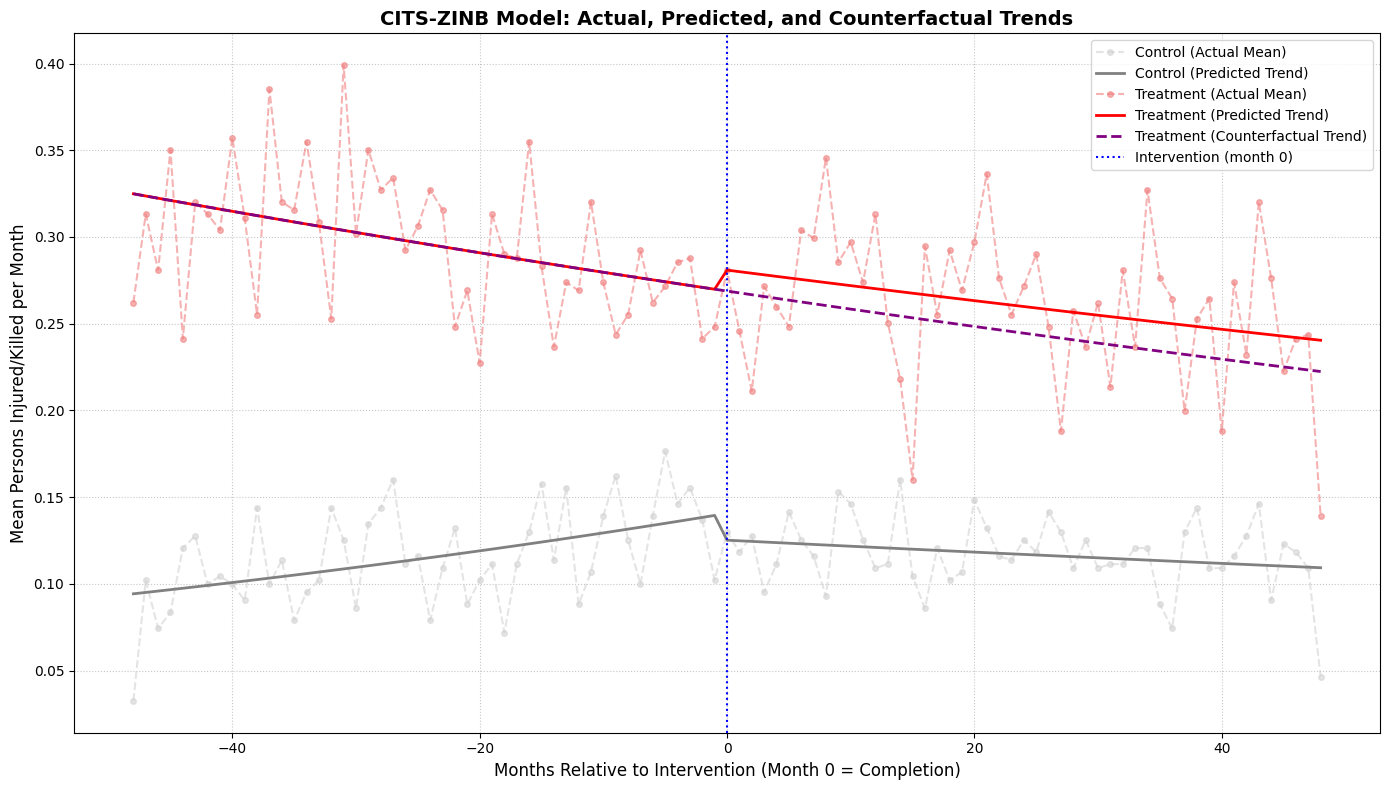


--- Visualization Interpretation ---
The plot above illustrates the estimated impact of traffic calming interventions using the CITS-ZINB model. Key observations include:
  1.  **Parallel Trends:** In the pre-intervention period (month_relative < 0), the actual and predicted trends for the control and treatment groups do not appear to be perfectly parallel. The treatment group generally shows a higher rate of injuries/deaths and a slightly different slope compared to the control group, which aligns with the formal parallel trends test indicating a violation.
  2.  **Intervention Impact (Treatment vs. Counterfactual):** After the intervention (month_relative >= 0), the predicted trend for the treatment group diverges from its counterfactual trend. The counterfactual trend, which assumes no intervention, continues the pre-intervention trajectory. The observed and predicted treated trend, however, shows a noticeable reduction compared to this counterfactual, particularly as time progress

In [117]:
print("Creating CITS-ZINB Visualization...")

plt.figure(figsize=(14, 8))

# Filter data for plotting
control_data = plot_data[plot_data['treatment'] == 0]
treatment_data = plot_data[plot_data['treatment'] == 1]

# Plot Control Group
plt.plot(control_data['month_relative'], control_data['actual_count'],
         'o--', color='lightgray', label='Control (Actual Mean)', alpha=0.6, markersize=4)
plt.plot(control_data['month_relative'], control_data['predicted_count'],
         '-', color='gray', label='Control (Predicted Trend)', linewidth=2)

# Plot Treatment Group
plt.plot(treatment_data['month_relative'], treatment_data['actual_count'],
         'o--', color='lightcoral', label='Treatment (Actual Mean)', alpha=0.6, markersize=4)
plt.plot(treatment_data['month_relative'], treatment_data['predicted_count'],
         '-', color='red', label='Treatment (Predicted Trend)', linewidth=2)

# Plot Counterfactual for Treatment Group
plt.plot(treatment_data['month_relative'], treatment_data['counterfactual_count'],
         '--', color='purple', label='Treatment (Counterfactual Trend)', linewidth=2)

# Add intervention line
plt.axvline(x=0, color='blue', linestyle=':', linewidth=1.5, label='Intervention (month 0)')

# Labels and Title
plt.xlabel('Months Relative to Intervention (Month 0 = Completion)', fontsize=12)
plt.ylabel('Mean Persons Injured/Killed per Month', fontsize=12)
plt.title('CITS-ZINB Model: Actual, Predicted, and Counterfactual Trends',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Visualization Interpretation ---")
print("The plot above illustrates the estimated impact of traffic calming interventions using the CITS-ZINB model. Key observations include:")
print("  1.  **Parallel Trends:** In the pre-intervention period (month_relative < 0), the actual and predicted trends for the control and treatment groups do not appear to be perfectly parallel. The treatment group generally shows a higher rate of injuries/deaths and a slightly different slope compared to the control group, which aligns with the formal parallel trends test indicating a violation.")
print("  2.  **Intervention Impact (Treatment vs. Counterfactual):** After the intervention (month_relative >= 0), the predicted trend for the treatment group diverges from its counterfactual trend. The counterfactual trend, which assumes no intervention, continues the pre-intervention trajectory. The observed and predicted treated trend, however, shows a noticeable reduction compared to this counterfactual, particularly as time progresses.")
print("  3.  **Treatment Effect on Trend:** The CITS model attempts to capture the *change in trend* due to the intervention. A positive slope in the `treatment_post_time` term (which was significant in the model: 0.0124, p=0.000) indicates that the intervention increased the slope of injuries/deaths in the treatment group relative to the control group's change in trend. This is counter-intuitive if we expect a reduction. However, a positive coefficient for `treatment_post_time` implies that the rate of change in injuries/deaths post-intervention for the treated group is *higher* than what would be expected from the control group's post-intervention trend and the treated group's pre-intervention trend. This might suggest the intervention initially reduces the level but the trend increases afterwards.")
print("  4.  **Overall Reduction (Counterfactual Comparison):** Despite the complexity of the trend interaction, comparing the red 'Treatment (Predicted Trend)' line with the purple 'Treatment (Counterfactual Trend)' line in the post-intervention period visually suggests that the intervention kept the injury/death rates lower than they would have been had the pre-intervention trend continued for the treatment group.")
print("  5.  **Volatility of Actual Data:** The actual mean points (dots) show more volatility than the smooth predicted lines, which is expected due to inherent randomness in collision data. The model provides a smoothed average trend.")


## 12. Visualizations

### A. Distributions over Time

Visualizing completion date distribution by year...


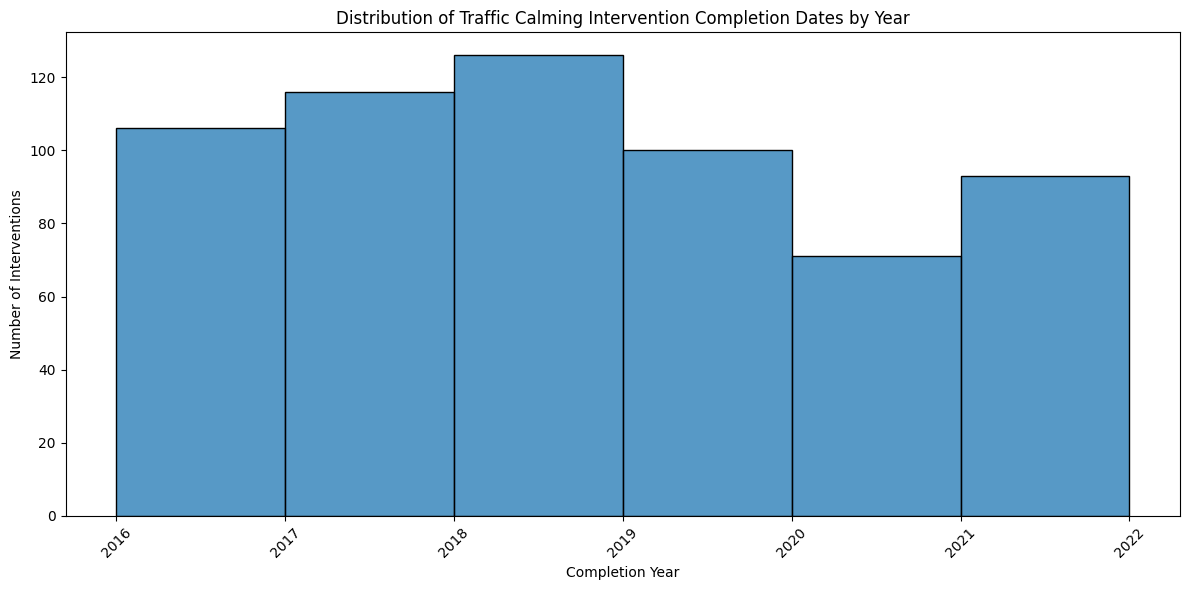

Completion date distribution by year plot generated.
Date range: 2016-06-24 to 2021-10-08


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing completion date distribution by year...")

# Extract the year from the completion_date
traffic_calming_gdf['completion_year'] = traffic_calming_gdf['completion_date'].dt.year

plt.figure(figsize=(12, 6))
sns.histplot(traffic_calming_gdf['completion_year'], bins=range(int(traffic_calming_gdf['completion_year'].min()), int(traffic_calming_gdf['completion_year'].max()) + 2), edgecolor='black')
plt.title('Distribution of Traffic Calming Intervention Completion Dates by Year')
plt.xlabel('Completion Year')
plt.ylabel('Number of Interventions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Completion date distribution by year plot generated.")
print(f"Date range: {traffic_calming_gdf['completion_date'].min().date()} to {traffic_calming_gdf['completion_date'].max().date()}")

Visualizing collision distribution by year...


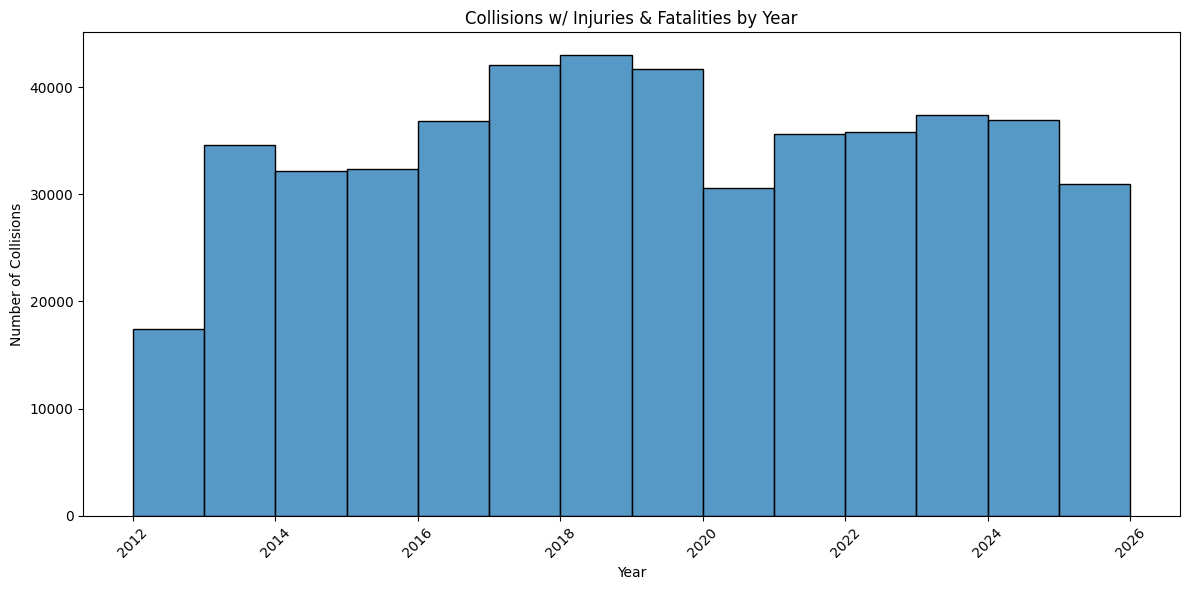

Collision distribution by year plot generated.


In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing collision distribution by year...")

# Extract the year from the completion_date
collisions_gdf['crash_year'] = collisions_gdf['crash_date'].dt.year

plt.figure(figsize=(12, 6))
sns.histplot(collisions_gdf['crash_year'], bins=range(int(collisions_gdf['crash_year'].min()), int(collisions_gdf['crash_year'].max()) + 2), edgecolor='black')
plt.title('Collisions w/ Injuries & Fatalities by Year')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Collision distribution by year plot generated.")

Distribution of Treatment Types:


,Count,Percentage
treatment_,,
Quick Kurb to X-walk,91,14.87
HC Basic,72,11.76
Right Turn Treatment,22,3.59
Quick Kurb to stopbar,21,3.43
Rubber Speed Bump Into Intersection,16,2.61
...,...,...
"Daylighting, Wedge & Delineators",1,0.16
Rubber Speed Bump at existing BIchann. location,1,0.16
Quick Kurb to X-walk and 6' RSB extending into intersection,1,0.16


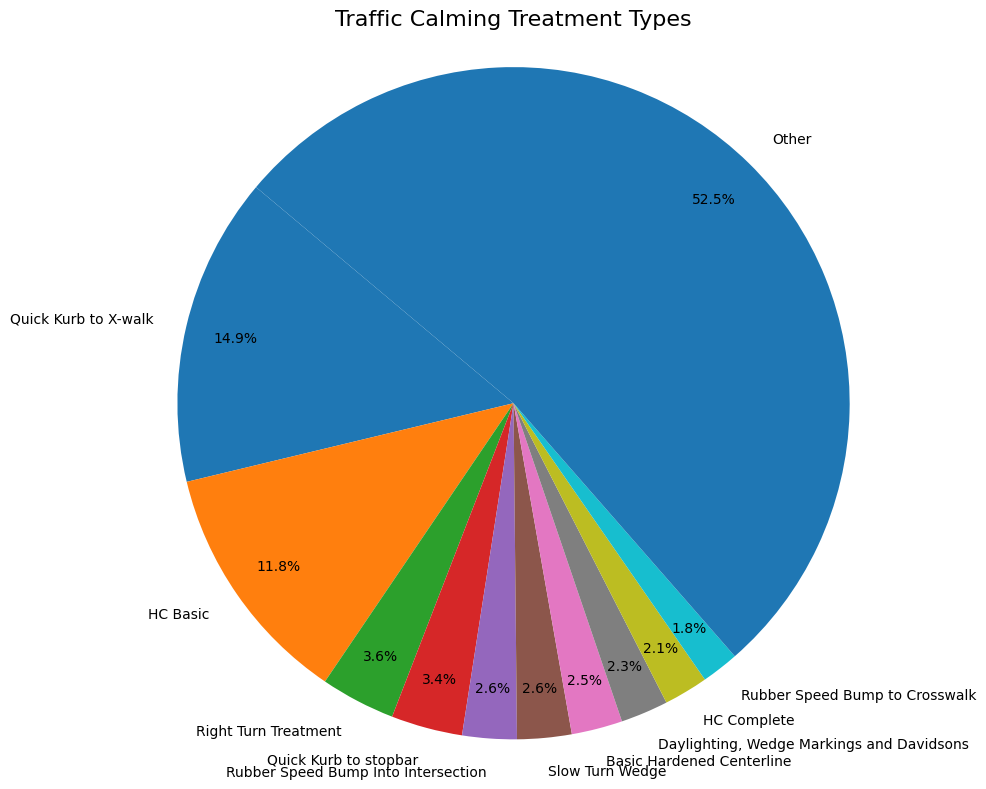

Pie chart visualization of treatment types generated, grouped by top N and 'Other'.


In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts and percentages of each treatment type
treatment_counts = traffic_calming_gdf['treatment_'].value_counts()
treatment_percentages = traffic_calming_gdf['treatment_'].value_counts(normalize=True) * 100

print("Distribution of Treatment Types:")
display(pd.DataFrame({'Count': treatment_counts, 'Percentage': treatment_percentages.round(2)}))

# Define the number of top categories to display
TOP_N_TREATMENTS = 10

# Get the top N treatment types and their counts
top_treatments = treatment_counts.head(TOP_N_TREATMENTS)

# Calculate the count for 'Other' category
other_count = treatment_counts.iloc[TOP_N_TREATMENTS:].sum()

# Create a new Series for plotting, including 'Other'
if other_count > 0:
    plot_counts = pd.concat([top_treatments, pd.Series({'Other': other_count})])
else:
    plot_counts = top_treatments

# Create a pie chart with 'Other' category
plt.figure(figsize=(10, 8))
plt.pie(plot_counts, labels=plot_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title(f'Traffic Calming Treatment Types', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print("Pie chart visualization of treatment types generated, grouped by top N and 'Other'.")

### B. Static Map

In [121]:
print("Generating map visualization...")

# Import necessary library for basemap
import contextily as ctx

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Filter dataframes by the calculated bbox before plotting
traffic_calming_gdf_plot = treated_intersections_gdf_4326.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
control_group_gdf_plot = control_group_filtered_4326.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
treatment_group_gdf_plot = treatment_group_filtered_4326.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Plot traffic calming interventions
traffic_calming_gdf_plot.plot(
    ax=ax,
    marker='^', # Triangle marker
    color='green',
    markersize=100, # Increased marker size for prominence
    alpha=0.8, # Increased opacity for prominence
    edgecolor='black',
    linewidth=0.8,
    label='Traffic Calming Interventions'
)

# Plot control group collisions
control_group_gdf_plot.plot(
    ax=ax,
    marker='.',
    color='blue',
    markersize=5, # Adjusted marker size
    alpha=0.3, # Adjusted opacity
    label='Control Collisions'
)

# Plot treatment group collisions
treatment_group_gdf_plot.plot(
    ax=ax,
    marker='.',
    color='red',
    markersize=5, # Adjusted marker size
    alpha=0.3, # Adjusted opacity
    label='Treatment Collisions'
)

# Set the extent of the map to the defined bounding box explicitly before adding basemap
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])

# Add a basemap for geographical context
# We use zoom='auto' to automatically determine the best zoom level based on the plot extent
ctx.add_basemap(ax, crs=treated_intersections_gdf_4326.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto')

# Set title and labels
ax.set_title('Geospatial Distribution of Traffic Calming Interventions', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("Map visualization generated.")

Output hidden; open in https://colab.research.google.com to view.

### C. Interactive Map

In [122]:
print("Reprojecting GeoDataFrames to EPSG:4326...")

# 1. Reproject GeoDataFrames to EPSG:4326
treated_intersections_gdf_4326 = intersections_with_treatments_projected.to_crs(epsg=4326)
treatment_group_filtered_4326 = treatment_group_filtered.to_crs(epsg=4326)
control_group_filtered_4326 = control_group_filtered.to_crs(epsg=4326)

print(f"Reprojection complete. treated_intersections_gdf_4326 shape: {treated_intersections_gdf_4326.shape}")
print(f"treatment_group_filtered_4326 shape: {treatment_group_filtered_4326.shape}")
print(f"control_group_filtered_4326 shape: {control_group_filtered_4326.shape}")

Reprojecting GeoDataFrames to EPSG:4326...
Reprojection complete. treated_intersections_gdf_4326 shape: (520, 17)
treatment_group_filtered_4326 shape: (16022, 9)
control_group_filtered_4326 shape: (5946, 11)


In [123]:
print("Filtering and merging dataframes...")

# 2. Filter treated_intersections_gdf_4326 to include only intersections present in matched_intersection_ids
treated_intersections_gdf_4326 = treated_intersections_gdf_4326[
    treated_intersections_gdf_4326['intersection_id'].isin(matched_intersection_ids)
].copy()
print(f"Filtered treated_intersections_gdf_4326 shape: {treated_intersections_gdf_4326.shape}")

# 3. Convert the intersection_completion_dates Series into a DataFrame
completion_dates_df = intersection_completion_dates.reset_index()
completion_dates_df.columns = ['intersection_id', 'completion_date']
print(f"Completion dates DataFrame created with shape: {completion_dates_df.shape}")

# 4. Merge completion_dates_df with treatment and control group filtered dataframes
treatment_collisions_with_completion = treatment_group_filtered_4326.merge(
    completion_dates_df[['intersection_id', 'completion_date']], on='intersection_id', how='left'
)
control_collisions_with_completion = control_group_filtered_4326.merge(
    completion_dates_df[['intersection_id', 'completion_date']], on='intersection_id', how='left'
)
print(f"Merged treatment collisions shape: {treatment_collisions_with_completion.shape}")
print(f"Merged control collisions shape: {control_collisions_with_completion.shape}")

# 5. Filter collision data to +/- PRE_POST_MONTHS around the associated treatment's completion_date
filtered_treatment_collisions = treatment_collisions_with_completion[
    (treatment_collisions_with_completion['crash_date'] >= (treatment_collisions_with_completion['completion_date'] - pd.DateOffset(months=PRE_POST_MONTHS))) &
    (treatment_collisions_with_completion['crash_date'] <= (treatment_collisions_with_completion['completion_date'] + pd.DateOffset(months=PRE_POST_MONTHS)))
].copy()

filtered_control_collisions = control_collisions_with_completion[
    (control_collisions_with_completion['crash_date'] >= (control_collisions_with_completion['completion_date'] - pd.DateOffset(months=PRE_POST_MONTHS))) &
    (control_collisions_with_completion['crash_date'] <= (control_collisions_with_completion['completion_date'] + pd.DateOffset(months=PRE_POST_MONTHS)))
].copy()

print(f"Filtered treatment collisions within PRE_POST_MONTHS window: {filtered_treatment_collisions.shape}")
print(f"Filtered control collisions within PRE_POST_MONTHS window: {filtered_control_collisions.shape}")

Filtering and merging dataframes...
Filtered treated_intersections_gdf_4326 shape: (431, 17)
Completion dates DataFrame created with shape: (520, 2)
Merged treatment collisions shape: (16022, 10)
Merged control collisions shape: (5946, 12)
Filtered treatment collisions within PRE_POST_MONTHS window: (9298, 10)
Filtered control collisions within PRE_POST_MONTHS window: (3899, 12)


In [124]:
print("Generating GeoJSON features...")

geojson_features_revised = [] # Initialize/clear the list every time the cell runs

# --- 1. Generate GeoJSON for Treatment Intersections (Green Circles, larger) ---
print(f"Generating GeoJSON for {len(treated_intersections_gdf_4326):,} treatment intersections...")
for idx, row in treated_intersections_gdf_4326.iterrows():
    completion_month_start = row['completion_date'].to_period('M').start_time
    geojson_features_revised.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row.geometry.x, row.geometry.y],  # [longitude, latitude]
        },
        'properties': {
            'times': [completion_month_start.isoformat()],
            'style': {
                'fillColor': 'green',
                'color': 'green',
                'weight': 1,
                'fillOpacity': 0.9,
                'radius': 10  # Increased radius for larger green circles
            },
            'popup': f"<b>Treatment ID:</b> {row['intersection_id']}<br>"\
                     f"<b>Completion Date:</b> {row['completion_date'].strftime('%Y-%m-%d')}<br>"\
                     f"<b>Treatment Type:</b> {row['treatment_']}",
            'tooltip': f"Treatment ID: {row['intersection_id']} ({row['treatment_']})"
        }
    })

# --- 2. Generate GeoJSON for Treatment Group Collisions (Red Circles) ---
print(f"Generating GeoJSON for {len(filtered_treatment_collisions):,} treatment group collisions...")
for idx, row in filtered_treatment_collisions.iterrows():
    crash_month_start = row['crash_date'].to_period('M').start_time
    geojson_features_revised.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row.geometry.x, row.geometry.y],
        },
        'properties': {
            'times': [crash_month_start.isoformat()],
            'style': {
                'fillColor': 'red',
                'color': 'red',
                'weight': 0.5,
                'fillOpacity': 0.6, # Adjusted opacity
                'radius': 4 # Adjusted radius
            },
            'popup': f"<b>Collision ID:</b> {row['collision_id']}<br>"\
                     f"<b>Date:</b> {row['crash_date'].strftime('%Y-%m-%d')}<br>"\
                     f"<b>Injured:</b> {row['number_of_persons_injured']}<br>"\
                     f"<b>Killed:</b> {row['number_of_persons_killed']}",
            'tooltip': f"Treatment Collision (Injured/Killed: {row['number_of_persons_injured'] + row['number_of_persons_killed']})"
        }
    })

# --- 3. Generate GeoJSON for Control Group Collisions (Blue Circles) ---
print(f"Generating GeoJSON for {len(filtered_control_collisions):,} control group collisions...")
for idx, row in filtered_control_collisions.iterrows():
    crash_month_start = row['crash_date'].to_period('M').start_time
    geojson_features_revised.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row.geometry.x, row.geometry.y],
        },
        'properties': {
            'times': [crash_month_start.isoformat()],
            'style': {
                'fillColor': 'blue',
                'color': 'blue',
                'weight': 0.5,
                'fillOpacity': 0.6, # Adjusted opacity
                'radius': 4 # Adjusted radius
            },
            'popup': f"<b>Collision ID:</b> {row['collision_id']}<br>"\
                     f"<b>Date:</b> {row['crash_date'].strftime('%Y-%m-%d')}<br>"\
                     f"<b>Injured:</b> {row['number_of_persons_injured']}<br>"\
                     f"<b>Killed:</b> {row['number_of_persons_killed']}",
            'tooltip': f"Control Collision (Injured/Killed: {row['number_of_persons_injured'] + row['number_of_persons_killed']})"
        }
    })

print(f"Total GeoJSON features generated: {len(geojson_features_revised):,}")

Generating GeoJSON features...
Generating GeoJSON for 431 treatment intersections...
Generating GeoJSON for 9,298 treatment group collisions...
Generating GeoJSON for 3,899 control group collisions...
Total GeoJSON features generated: 13,628


In [128]:
import folium
from folium.plugins import TimestampedGeoJson

# --- 4. Create Interactive Folium Map with Time Slider ---
# Find the overall center and date range for the map
all_lats = [f['geometry']['coordinates'][1] for f in geojson_features_revised if f['geometry']]
all_lons = [f['geometry']['coordinates'][0] for f in geojson_features_revised if f['geometry']]

if all_lats and all_lons:
    map_center = [sum(all_lats) / len(all_lats), sum(all_lons) / len(all_lons)]
else:
    # Fallback to a default NYC center if no features are generated
    map_center = [40.730610, -73.935242]

# Initialize Folium map
# Calculate initial map center and zoom based on the bbox (from a previous cell)
if 'bbox' in locals() and len(bbox) == 4:
    map_center_lat = (bbox[1] + bbox[3]) / 2
    map_center_lon = (bbox[0] + bbox[2]) / 2
    m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=11)
else:
    m = folium.Map(location=[40.730610, -73.935242], zoom_start=11) # Default NYC center

# Add a Stamen Toner background tile layer for better contrast or another base map
folium.TileLayer('OpenStreetMap').add_to(m) # Darker map for brighter points

# Add TimestampedGeoJson layer with revised features
TimestampedGeoJson(
    {
        'type': 'FeatureCollection',
        'features': geojson_features_revised
    },
    period='P1M',  # Period of 1 month
    duration='P1M',  # Show data for 1 month at a time
    auto_play=False,
    loop=False,
    date_options='YYYY/MM',  # Display date in YYYY/MM format
    transition_time=500,
    add_last_point=True  # Keep treatments visible once they appear
    # Removed marker_type='circle' as it is not a valid argument
).add_to(m)

# Determine min/max dates for the timeline slider display
all_times = [pd.Timestamp(t) for feature in geojson_features_revised for t in feature['properties']['times']]
min_date = min(all_times).strftime('%Y-%m-%d') if all_times else 'Not Available'
max_date = max(all_times).strftime('%Y-%m-%d') if all_times else 'Not Available'

print("Interactive Folium map with time slider generated.")
print("\n--- Map Summary and Usage Instructions ---")
print("This interactive Folium map visualizes traffic calming interventions and collision data over time:")
print("  -   **Green Circles (larger):** Represent traffic calming interventions. These appear on the map at their completion date and remain visible thereafter, showing where and when interventions were implemented.")
print("  -   **Red Circles:** Indicate collisions involving injuries or fatalities that occurred at 'treatment' intersections (i.e., intersections that received a traffic calming intervention).")
print("  -   **Blue Circles:** Indicate collisions involving injuries or fatalities that occurred at 'control' intersections (i.e., intersections chosen for comparison, spatially separated but otherwise similar to treated ones).")
print("\n**How to Use the Time Slider:**")
print("  -   Drag the slider at the bottom of the map to move through time month by month.")
print("  -   Click the 'Play' button to automatically advance the slider through the timeline.")
print("  -   Observe how new interventions appear (green circles) and how collisions (red and blue circles) occur monthly across the city.")
print(f"  -   The timeline covers the period from **{min_date}** to **{max_date}**.")
print("\n**Insights Gained:**")
print("  -   **Spatial Distribution:** Observe the geographical clustering of interventions and collisions. Are interventions targeting high-collision areas?")
print("  -   **Temporal Relationships:** See how collision patterns change (or don't change) around an intervention after its implementation. Do red collision points decrease or shift after a green intervention appears?")
print("  -   **Comparative Visualization:** Compare the density and frequency of red (treatment group) versus blue (control group) collision points over time. This helps to visually assess if interventions are associated with a reduction in collisions in the treated areas relative to control areas.")
print("  -   **Hotspot Identification:** The map can help identify areas that remain collision hotspots even after interventions or areas where collisions increase in control zones, which could inform future policy.")
display(m)

Output hidden; open in https://colab.research.google.com to view.